# India Dark Store & Q-Commerce EDA (2015–2025)
## From Dunzo's Hyperlocal Roots to Blinkit's 10-Minute Revolution

> **Dataset:** Synthetic NPCI/Inc42/ET-calibrated individual order records  
> **Period:** 2015 – 2025 (11 Years)  
> **Total Records:** ~48.3 Lakh rows across 11 files  
> **Apps Covered:** Dunzo (2015) · Amazon Fresh (2019) · Swiggy Instamart (2020) · Blinkit/Zepto/BB Now (2021) · Flipkart Minutes (2024)  
> **Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

### What This Notebook Answers
| # | Question |
|---|----------|
| 1 | How did Q-Commerce grow from ₹250 AOV (2015) to ₹650 AOV (2025)? |
| 2 | Which app dominates — and how did market share evolve? |
| 3 | How did Tier 2/3 city expansion happen over the years? |
| 4 | When do people order most — hour, day, season? |
| 5 | Which categories drive maximum orders and revenue? |
| 6 | How has delivery speed improved from 45 min to under 10 min? |
| 7 | UPI vs Credit Card — how did payments evolve? |
| 8 | Festive season spike — Diwali effect on Q-Commerce? |
| 9 | How did COVID-19 (2020) reshape consumer behavior? |
| 10 | New vs Returning vs Premium users — retention patterns? |

### App Launch Timeline (Verified from Inc42 / ET / official sources)
| App | Founded | Q-Com Start | Status (2025) |
|-----|---------|-------------|--------------|
| Dunzo Daily | 2015 | 2015 | Shut down 2025 |
| Amazon Fresh | 2019 | 2019 | Active |
| Swiggy Instamart | Aug 2020 | Aug 2020 | Active (25% share) |
| Blinkit (Grofers) | 2013 | Aug 2021 | Active (50%+ share) |
| Zepto | 2021 | 2021 | Active (20% share) |
| BigBasket BB Now | 2021 | 2021 | Active |
| Flipkart Minutes | 2024 | 2024 | Active, 19 cities |

---


##  Phase 1 — Imports & Configuration

In [1]:
# Standard-library utilities 
import os          # Directory creation, path manipulation
import gc          # Manual garbage collection for large DataFrames
import warnings    # Suppress noisy but harmless library warnings
from datetime import datetime   # Timestamp-based file naming / feature engineering

# Core data stack 
import pandas as pd    # DataFrame operations — loading, slicing, groupby, merge
import numpy as np     # Vectorised math, random-number generation, array ops

# Visualisation Libaries
import matplotlib.pyplot as plt          # Low-level figure / axes control
import matplotlib.ticker as mtick        # Axis formatters (%, currency, etc.)
import seaborn as sns                    # High-level statistical chart wrappers
import plotly.express as px              # One-liner interactive charts
from plotly.subplots import make_subplots  # Multi-panel plotly figure layouts
import plotly.graph_objects as go        # Fine-grained plotly trace control

# Warnings settings 
warnings.filterwarnings('ignore')        # Silence deprecation / future warnings
os.makedirs('visuals', exist_ok=True)   # Create output folder (no-op if exists)

# MATPLOTLIB GLOBAL THEME
plt.rcParams.update({
    'figure.figsize'    : (13, 5),
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
})

# BRAND / SEMANTIC COLOUR PALETTE
COLORS = {
    # Quick-commerce platform
    'blinkit'    : '#F9C22E',   # Blinkit yellow
    'zepto'      : '#8B2FC9',   # Zepto violet
    'instamart'  : '#FC8019',   # Swiggy Instamart orange
    'bbnow'      : '#84CC16',   # BigBasket BB Now lime-green
    'dunzo'      : '#3B82F6',   # Dunzo Daily blue
    'amazon'     : '#F97316',   # Amazon Fresh orange
    'flipkart'   : '#2563EB',   # Flipkart Minutes blue

    # City-tier segmentation
    'tier1'      : '#1E3A5F',   # Tier-1 metros — dark navy (largest markets)
    'tier2'      : '#2563EB',   # Tier-2 cities — medium blue
    'tier3'      : '#60A5FA',   # Tier-3 cities — light blue (emerging)

    # Order-status indicator
    'delivered'  : '#16A34A',   # Green — successful delivery
    'cancelled'  : '#DC2626',   # Red   — cancellation
    'returned'   : '#D97706',   # Amber — return / refund

    # Misc semantic roles 
    'festive'    : '#F59E0B',   # Highlight for festive-season data points
    'primary'    : '#1E3A5F',   # Default accent — headings, single-series charts
}

APP_COLORS = {
    'Blinkit'          : COLORS['blinkit'],
    'Zepto'            : COLORS['zepto'],
    'Swiggy Instamart' : COLORS['instamart'],
    'BigBasket BB Now' : COLORS['bbnow'],
    'Dunzo Daily'      : COLORS['dunzo'],
    'Amazon Fresh'     : COLORS['amazon'],
    'Flipkart Minutes' : COLORS['flipkart'],
}

print('All Libraries loaded')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')
print(f'   Seaborn : {sns.__version__}')

All Libraries loaded
   Pandas  : 2.3.3
   NumPy   : 2.3.5
   Seaborn : 0.13.2


##  Phase 2 — Load Data (from MySQL, year-wise tables)

In [2]:
# ── Step 1: Connect to MySQL ──
from sqlalchemy import create_engine, text

MYSQL_USER, MYSQL_PASSWORD = "root", "shubham75"
MYSQL_HOST, MYSQL_PORT     = "127.0.0.1", 3306
MYSQL_DATABASE             = "qcommerce_db"

engine = create_engine(f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}")
print(f"Connected to MySQL → {MYSQL_DATABASE}")

Connected to MySQL → qcommerce_db


In [3]:
# ── Step 2: Confirm all 11 year-wise tables are visible before fetching ──
with engine.connect() as conn:
    tables_df = pd.read_sql(text("SHOW TABLES LIKE 'qcommerce_orders_%'"), conn)

table_list = tables_df.iloc[:, 0].tolist()
year_tables = sorted([t for t in table_list if t != "qcommerce_orders_all"])

print(f"Tables found: {len(table_list)} total")
print(f"Year-wise tables: {len(year_tables)}")
for t in year_tables:
    print(f"{t}")
print(f"View present: {"qcommerce_orders_all" in table_list}")

Tables found: 12 total
Year-wise tables: 11
qcommerce_orders_2015
qcommerce_orders_2016
qcommerce_orders_2017
qcommerce_orders_2018
qcommerce_orders_2019
qcommerce_orders_2020
qcommerce_orders_2021
qcommerce_orders_2022
qcommerce_orders_2023
qcommerce_orders_2024
qcommerce_orders_2025
View present: True


In [4]:
# ── Step 3: Fetch each year's table individually and concatenate ──
# (Mirrors the original per-CSV loop, just sourced from MySQL instead of disk)

years   = list(range(2015, 2026))
all_dfs = []

for year in years:
    table_name = f"qcommerce_orders_{year}"
    query = f"SELECT * FROM {table_name}"

    with engine.connect() as conn:
        df_yr = pd.read_sql(text(query), conn)

    all_dfs.append(df_yr)
    apps_this_year = sorted(df_yr["app"].unique().tolist())
    print(f"  {year} → {len(df_yr):>9,} rows | Apps: {apps_this_year}")

# ── Step 4: Combine all years into one big DataFrame ──
df = pd.concat(all_dfs, ignore_index=True)
del all_dfs
gc.collect()

print(f"\n Combined Dataset Ready (sourced from MySQL)!")
print(f"   Total Rows    : {df.shape[0]:,}")
print(f"   Total Columns : {df.shape[1]}")
print(f"   Memory Used   : {df.memory_usage(deep=True).sum()/1024/1024:.0f} MB")

  2015 →   100,000 rows | Apps: ['Dunzo Daily']
  2016 →   150,000 rows | Apps: ['Dunzo Daily']
  2017 →   200,000 rows | Apps: ['Dunzo Daily']
  2018 →   250,000 rows | Apps: ['Dunzo Daily']
  2019 →   350,000 rows | Apps: ['Amazon Fresh', 'Dunzo Daily']
  2020 →   550,000 rows | Apps: ['Amazon Fresh', 'Dunzo Daily', 'Swiggy Instamart']
  2021 → 1,000,000 rows | Apps: ['Amazon Fresh', 'BigBasket BB Now', 'Blinkit', 'Dunzo Daily', 'Swiggy Instamart', 'Zepto']
  2022 → 1,400,000 rows | Apps: ['Amazon Fresh', 'BigBasket BB Now', 'Blinkit', 'Dunzo Daily', 'Swiggy Instamart', 'Zepto']
  2023 → 1,600,000 rows | Apps: ['BigBasket BB Now', 'Blinkit', 'Dunzo Daily', 'Swiggy Instamart', 'Zepto']
  2024 → 1,900,000 rows | Apps: ['BigBasket BB Now', 'Blinkit', 'Flipkart Minutes', 'Swiggy Instamart', 'Zepto']
  2025 → 2,500,000 rows | Apps: ['BigBasket BB Now', 'Blinkit', 'Flipkart Minutes', 'Swiggy Instamart', 'Zepto']

 Combined Dataset Ready (sourced from MySQL)!
   Total Rows    : 10,000,000
 

In [5]:
# Column names and dtypes — first structural check
print("=== Column Names ===")
print(list(df.columns))

print()

print("=== Data Types ===")
print(df.dtypes)

=== Column Names ===
['order_id', 'datetime', 'date', 'year', 'month', 'month_name', 'day', 'day_of_week', 'hour', 'is_weekend', 'is_festive_season', 'app', 'city', 'city_tier', 'category', 'items_ordered', 'order_amount_rs', 'discount_rs', 'final_amount_rs', 'delivery_fee_rs', 'payment_mode', 'delivery_slot', 'delivery_time_min', 'dark_store_id', 'order_status', 'cancel_return_reason', 'customer_rating', 'age_group', 'gender', 'user_type', 'customer_lifetime_orders', 'days_since_last_order', 'promo_code_used', 'estimated_delivery_distance_km']

=== Data Types ===
order_id                           object
datetime                           object
date                               object
year                                int64
month                               int64
month_name                         object
day                                 int64
day_of_week                        object
hour                                int64
is_weekend                          int64
is_festiv

In [6]:
# Quick visual check — confirm values look realistic
df.head()

,order_id,datetime,date,year,month,month_name,day,day_of_week,hour,is_weekend,...,order_status,cancel_return_reason,customer_rating,age_group,gender,user_type,customer_lifetime_orders,days_since_last_order,promo_code_used,estimated_delivery_distance_km
0,QC2015000000001,2015-11-25 20:00:00,2015-11-25,2015,11,November,25,Wednesday,20,0,...,Delivered,None,4.9,35-44,Male,Returning User,35.0,40.0,None,0.93
1,QC2015000000002,2015-06-01 15:03:00,2015-06-01,2015,6,June,1,Monday,15,0,...,Cancelled,Changed my mind,2.0,25-34,Female,New User,NaN,NaN,No Promo,0.94
2,QC2015000000003,2015-07-05 14:03:00,2015-07-05,2015,7,July,5,Sunday,14,1,...,Delivered,None,NaN,25-34,Female,Premium User,70.0,9.0,No Promo,0.97
3,QC2015000000004,2015-01-21 13:22:00,2015-01-21,2015,1,January,21,Wednesday,13,0,...,Delivered,None,3.8,25-34,Male,Returning User,17.0,29.0,Referral,1.07
4,QC2015000000005,2015-08-22 12:55:00,2015-08-22,2015,8,August,22,Saturday,12,1,...,Delivered,None,3.5,55+,Male,New User,NaN,NaN,No Promo,0.91


In [7]:
# Spot outliers, negatives, skewed distributions
print("=== Numeric Summary ===")

df[["order_amount_rs", "discount_rs", "final_amount_rs",
    "delivery_fee_rs", "delivery_time_min", "items_ordered",
    "customer_rating"]].describe().round(2)

=== Numeric Summary ===


,order_amount_rs,discount_rs,final_amount_rs,delivery_fee_rs,delivery_time_min,items_ordered,customer_rating
count,10000000.00,9700264.00,10000000.00,10000000.00,9800658.00,10000000.00,9026413.00
mean,681.66,59.71,623.74,12.67,26.64,3.53,3.99
std,363.23,82.96,340.91,16.61,17.63,1.82,0.71
min,99.00,0.00,69.30,0.00,5.00,1.00,1.00
25%,431.39,0.00,388.92,0.00,13.20,2.00,3.50
50%,606.58,27.23,551.89,0.00,21.20,3.00,4.00
75%,845.80,94.80,776.28,26.00,36.30,5.00,4.50
max,5000.00,1500.00,5000.00,50.00,136.70,17.00,5.00


## Phase 3A — Data Cleaning & Preprocessing

In [8]:
# 3.1 Check nulls
# Count missing values per column
null_counts = df.isnull().sum()

# Express as percentage of total rows
null_pct = (null_counts / len(df) * 100).round(3)

# Combine into one report table
null_report = pd.DataFrame({
    "null_count" : null_counts,
    "null_pct_%" : null_pct,
    "dtype"      : df.dtypes
})

# Keep only columns that have missing values
null_report = null_report[null_report["null_count"] > 0]

# Worst offenders at the top
null_report = null_report.sort_values("null_pct_%", ascending=False)

print("=== NULL VALUE REPORT ===")
print(null_report)

=== NULL VALUE REPORT ===
                                null_count  null_pct_%    dtype
cancel_return_reason               9134101      91.341   object
customer_lifetime_orders           2001740      20.017  float64
days_since_last_order              1897688      18.977  float64
customer_rating                     973587       9.736  float64
estimated_delivery_distance_km      679113       6.791  float64
promo_code_used                     500472       5.005   object
discount_rs                         299736       2.997  float64
delivery_time_min                   199342       1.993  float64


In [9]:
# 3.2 Fix Data Types
# Parse date columns from string to proper datetime
df["datetime"] = pd.to_datetime(df["datetime"])
df["date"]     = pd.to_datetime(df["date"])

# Columns with small fixed set of repeated text values
cat_cols = ["app", "city", "city_tier", "category", "payment_mode",
            "delivery_slot", "order_status", "cancel_return_reason",
            "age_group", "gender", "user_type", "day_of_week", "month_name"]

# category dtype stores one copy of each unique value — saves memory
for col in cat_cols:
    df[col] = df[col].astype("category")

print("Datetime parsed | Categoricals optimized")
print(f"   Memory after : {df.memory_usage(deep=True).sum()/1024/1024:.1f} MB")

Datetime parsed | Categoricals optimized
   Memory after : 3174.3 MB


In [10]:
# 3.3 — HANDLE NULLS
# customer_rating — fill with app-wise median

# Step 1: Create flag before filling — 1 if rating was originally missing
df["rating_was_missing"] = df["customer_rating"].isnull().astype(int)

# Step 2: Count nulls before filling
n_rating = df["customer_rating"].isnull().sum()

# Step 3: Calculate median rating per app
app_medians = df.groupby("app")["customer_rating"].median()

# Step 4: Fill missing ratings with app-wise median
for app_name, median_value in app_medians.items():
    mask = (df["app"] == app_name) & (df["customer_rating"].isnull())
    df.loc[mask, "customer_rating"] = median_value

# Step 5: Verify
print(app_medians)
print()
print(f"customer_rating  : {n_rating:,} nulls → filled with app-wise median")
print(f"rating_was_missing: {df['rating_was_missing'].sum():,} rows flagged as originally null")

app
Amazon Fresh        4.0
BigBasket BB Now    4.0
Blinkit             4.0
Dunzo Daily         4.0
Flipkart Minutes    4.0
Swiggy Instamart    4.0
Zepto               4.0
Name: customer_rating, dtype: float64

customer_rating  : 973,587 nulls → filled with app-wise median
rating_was_missing: 973,587 rows flagged as originally null


In [11]:
# 3.3.1 - Missing discount means no discount was applied on that order - fill with 0
n = df["discount_rs"].isnull().sum()
df["discount_rs"] = df["discount_rs"].fillna(0)
print(f"discount_rs : {n:,} nulls -> filled with 0")

discount_rs : 299,736 nulls -> filled with 0


In [12]:
# 3.3.2 Fill missing cancel_return_reason values 
# Step 1: Count nulls before filling
n = df['cancel_return_reason'].isnull().sum()
# Step 2: Add 'NA' as a new allowed category
#         (categorical columns only allow pre-defined values)
df['cancel_return_reason'] = df['cancel_return_reason'].cat.add_categories('NA')
# Step 3: Fill all missing values with 'NA'
df['cancel_return_reason'] = df['cancel_return_reason'].fillna('NA')
# Step 4: Print result
print(f"cancel_return_reason : {n} nulls → filled with NA")

cancel_return_reason : 9134101 nulls → filled with NA


In [13]:
# 3.3.3 - FILL MISSING DELIVERY TIMES

# Count nulls before filling
n = df["delivery_time_min"].isnull().sum()

# Calculate median delivery time separately for each delivery slot
slot_medians = df.groupby("delivery_slot")["delivery_time_min"].median()

# Fill missing values per slot
for slot_name, median_value in slot_medians.items():
    # Select rows where both conditions are true:
    #   1. row belongs to this slot
    #   2. delivery time is missing
    mask = (df["delivery_slot"] == slot_name) & (df["delivery_time_min"].isnull())
    df.loc[mask, "delivery_time_min"] = median_value
    
print(f"delivery_time_min : {n} nulls -> filled with slot-wise median")

delivery_time_min : 199342 nulls -> filled with slot-wise median


In [14]:
# 3.3.4 - FILL customer_lifetime_orders

# Count nulls before filling
n = df["customer_lifetime_orders"].isnull().sum()

# Fill missing lifetime orders with 1
# A New User placing their first order has exactly 1 lifetime order
df["customer_lifetime_orders"] = df["customer_lifetime_orders"].fillna(1)

# Convert to integer - order count should not be a decimal
df["customer_lifetime_orders"] = df["customer_lifetime_orders"].astype(int)

print(f"customer_lifetime_orders : {n:,} nulls -> filled with 1 (first-time order for New Users)")

customer_lifetime_orders : 2,001,740 nulls -> filled with 1 (first-time order for New Users)


In [15]:
# 3.3.5 - FILL days_since_last_order

# Count nulls before filling
n = df["days_since_last_order"].isnull().sum()

# Fill missing days with 0
# New Users have no previous order so days since last = 0
df["days_since_last_order"] = df["days_since_last_order"].fillna(0)

# Convert to integer - days should not be a decimal
df["days_since_last_order"] = df["days_since_last_order"].astype(int)

print(f"days_since_last_order : {n:,} nulls -> filled with 0 (no previous order for New Users)")

days_since_last_order : 1,897,688 nulls -> filled with 0 (no previous order for New Users)


In [16]:
# 3.3.6 - FILL promo_code_used

# Count nulls before filling
n = df["promo_code_used"].isnull().sum()

# Fill missing promo code with "Unknown"
# Random tracking failure - no way to know what promo was applied
df["promo_code_used"] = df["promo_code_used"].fillna("Unknown")

print(f"promo_code_used   : {n:,} nulls -> filled with Unknown (random tracking gap)")

promo_code_used   : 500,472 nulls -> filled with Unknown (random tracking gap)


In [17]:
# 3.3.7 - FILL estimated_delivery_distance_km   (MNAR)

# Count nulls before filling
n = df["estimated_delivery_distance_km"].isnull().sum()

# Step 1: Create flag column BEFORE filling
# distance_was_missing = 1 means GPS tracking failed for this order
df["distance_was_missing"] = df["estimated_delivery_distance_km"].isnull().astype(int)

# Step 2: Calculate median distance separately for each city tier
tier_medians = df.groupby(
    "city_tier", observed=True
)["estimated_delivery_distance_km"].median()

# Step 3: Fill missing distances using the median of the same city tier
for tier_name, median_value in tier_medians.items():
    mask = (df["city_tier"] == tier_name) & (df["estimated_delivery_distance_km"].isnull())
    df.loc[mask, "estimated_delivery_distance_km"] = median_value
    
# Step 4: If any nulls still remain (edge cases), fill with overall median
overall_median_dist = df["estimated_delivery_distance_km"].median()
df["estimated_delivery_distance_km"] = (
    df["estimated_delivery_distance_km"].fillna(overall_median_dist)
)

print(f"estimated_delivery_distance_km : {n:,} nulls -> flag created + filled with city_tier-wise median")

estimated_delivery_distance_km : 679,113 nulls -> flag created + filled with city_tier-wise median


In [18]:
df.columns

Index(['order_id', 'datetime', 'date', 'year', 'month', 'month_name', 'day',
       'day_of_week', 'hour', 'is_weekend', 'is_festive_season', 'app', 'city',
       'city_tier', 'category', 'items_ordered', 'order_amount_rs',
       'discount_rs', 'final_amount_rs', 'delivery_fee_rs', 'payment_mode',
       'delivery_slot', 'delivery_time_min', 'dark_store_id', 'order_status',
       'cancel_return_reason', 'customer_rating', 'age_group', 'gender',
       'user_type', 'customer_lifetime_orders', 'days_since_last_order',
       'promo_code_used', 'estimated_delivery_distance_km',
       'rating_was_missing', 'distance_was_missing'],
      dtype='object')

In [19]:
# 3.3.8 - FINAL NULL VERIFICATION

print()
print("NULL REPORT AFTER CLEANING")

null_after = df.isnull().sum()
null_after_nonzero = null_after[null_after > 0]

if len(null_after_nonzero) == 0:
    print("No null values remaining in dataset!")
else:
    print("Columns still having nulls:")
    print(null_after_nonzero)
print()
print("CLEANING SUMMARY")
print(f"{'Column':<40} {'Type':<6}  {'Method Used'}")
print("-" * 80)

summary = [
    ("discount_rs",                     "MCAR",  "fillna(0)"),
    ("delivery_time_min",               "MCAR",  "fillna(slot-wise median)"),
    ("cancel_return_reason",            "MAR",   "fillna(\"NA\")"),
    ("customer_lifetime_orders",        "MAR",   "fillna(1) - New Users"),
    ("days_since_last_order",           "MAR",   "fillna(0) - New Users"),
    ("promo_code_used",                 "MCAR",  "fillna(\"Unknown\")"),
    ("customer_rating",                 "MNAR",  "Flag -> fillna(app-wise median)"),
    ("estimated_delivery_distance_km",  "MNAR",  "Flag -> fillna(tier-wise median)")
]
for col, ntype, method in summary:
    print(f"{col:<40} {ntype:<6}  {method}")
print()
print("New columns added during cleaning:")
print("  rating_was_missing     -> 1 if customer_rating was originally null")
print("  distance_was_missing   -> 1 if delivery distance was originally null")
print()
print(f"Final dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns")


NULL REPORT AFTER CLEANING
No null values remaining in dataset!

CLEANING SUMMARY
Column                                   Type    Method Used
--------------------------------------------------------------------------------
discount_rs                              MCAR    fillna(0)
delivery_time_min                        MCAR    fillna(slot-wise median)
cancel_return_reason                     MAR     fillna("NA")
customer_lifetime_orders                 MAR     fillna(1) - New Users
days_since_last_order                    MAR     fillna(0) - New Users
promo_code_used                          MCAR    fillna("Unknown")
customer_rating                          MNAR    Flag -> fillna(app-wise median)
estimated_delivery_distance_km           MNAR    Flag -> fillna(tier-wise median)

New columns added during cleaning:
  rating_was_missing     -> 1 if customer_rating was originally null
  distance_was_missing   -> 1 if delivery distance was originally null

Final dataset shape : 10,000,00

## Phase 3B — Feature Engineering

In [20]:
# 3.4 — FEATURE ENGINEERING

# Quarter number from date
df["quarter"] = df["date"].dt.quarter

# 1 if order had a discount, 0 if not
df["has_discount"] = (df["discount_rs"] > 0).astype(int)

# Discount as percentage of original order amount
df["discount_pct"] = (df["discount_rs"] / df["order_amount_rs"] * 100).round(1)

# Group orders into price ranges
df["order_bucket"] = pd.cut(
    df["order_amount_rs"],
    bins   = [0, 200, 400, 600, 1000, 2000, 5001],
    labels = ["<₹200", "₹200-400", "₹400-600", "₹600-1K", "₹1K-2K", "₹2K+"]
)

# Copy delivery slot for speed analysis
df["speed_bucket"] = df["delivery_slot"].copy()

# Real-world launch year for each platform
launch_map = {
    "Dunzo Daily"      : 2015,
    "Amazon Fresh"     : 2019,
    "Swiggy Instamart" : 2020,
    "Blinkit"          : 2021,
    "Zepto"            : 2021,
    "BigBasket BB Now" : 2021,
    "Flipkart Minutes" : 2024,
}

# Map launch year onto every row
df["app_launch_year"]    = df["app"].map(launch_map)

# How old was the app when each order was placed
df["years_since_launch"] = df["year"] - df["app_launch_year"]

# 1 if payment was UPI, 0 for all other modes
df["is_upi"] = (df["payment_mode"] == "UPI").astype(int)

print("Feature engineering done")
new_cols = ["quarter", "has_discount", "discount_pct", "order_bucket",
            "app_launch_year", "years_since_launch", "is_upi"]
print(f"   New columns : {new_cols}")
print()

df[["datetime", "app", "city", "city_tier", "category", "order_amount_rs",
    "discount_rs", "delivery_slot", "delivery_time_min", "order_status"]].head(5)

Feature engineering done
   New columns : ['quarter', 'has_discount', 'discount_pct', 'order_bucket', 'app_launch_year', 'years_since_launch', 'is_upi']



,datetime,app,city,city_tier,category,order_amount_rs,discount_rs,delivery_slot,delivery_time_min,order_status
0,2015-11-25 20:00:00,Dunzo Daily,Ahmedabad,Tier 1,Medicines,245.19,0.00,20-30 min,23.0,Delivered
1,2015-06-01 15:03:00,Dunzo Daily,Bengaluru,Tier 1,Household,222.96,66.89,60+ min,79.1,Cancelled
2,2015-07-05 14:03:00,Dunzo Daily,Mumbai,Tier 1,Dairy & Eggs,613.70,0.00,20-30 min,28.9,Delivered
3,2015-01-21 13:22:00,Dunzo Daily,Hyderabad,Tier 1,Baby Products,387.19,38.72,20-30 min,21.5,Delivered
4,2015-08-22 12:55:00,Dunzo Daily,Hyderabad,Tier 1,Electronics,212.28,53.07,60+ min,59.0,Delivered


## Phase 4 — Univariate Analysis

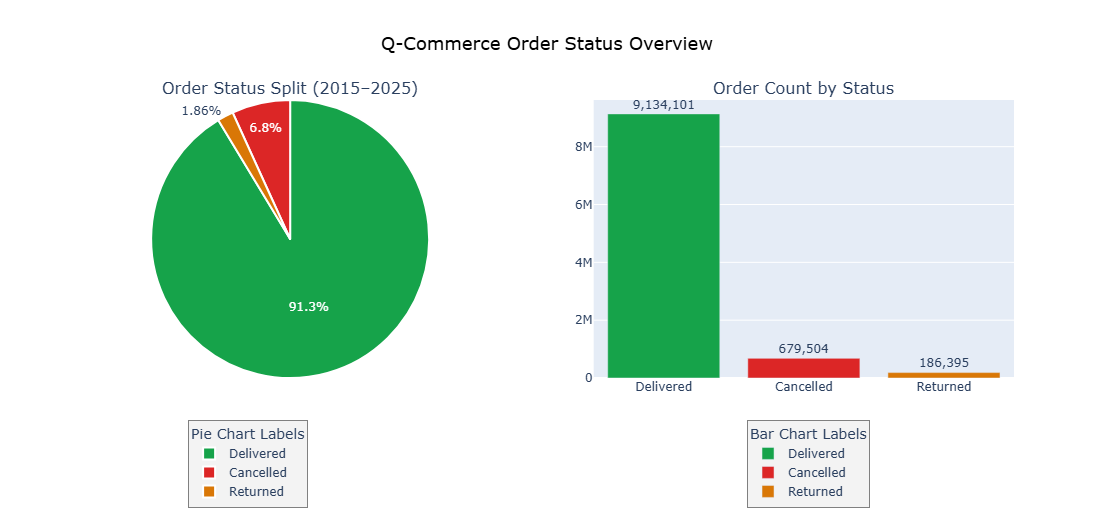

order_status
Delivered    9134101
Cancelled     679504
Returned      186395
Name: count, dtype: int64


In [21]:
# CHART 4.1 — ORDER STATUS DISTRIBUTION

# Count orders per status
st_cnt         = df["order_status"].value_counts().reset_index()
st_cnt.columns = ["status", "count"]

# Status colours from COLORS dict
status_colors = {
    "Delivered" : COLORS["delivered"],  # Green
    "Cancelled" : COLORS["cancelled"],  # Red
    "Returned"  : COLORS["returned"],   # Amber
}

colors = [status_colors.get(s, "#94A3B8") for s in st_cnt["status"]]

fig = make_subplots(
    rows           = 1, cols = 2,
    specs          = [[{"type": "pie"}, {"type": "bar"}]],
    subplot_titles = ["Order Status Split (2015–2025)", "Order Count by Status"]
)

fig.add_trace(
    go.Pie(
        labels        = st_cnt["status"],
        values        = st_cnt["count"],
        marker        = dict(colors=colors, line=dict(color="white", width=2)),
        textinfo      = "percent",
        textfont_size = 12,
        legend        = "legend",
        name          = "Status Split"
    ),
    row=1, col=1
)

for i, row in st_cnt.iterrows():
    fig.add_trace(
        go.Bar(
            x            = [row["status"]],
            y            = [row["count"]],
            name         = row["status"],
            marker_color = status_colors.get(row["status"], "#94A3B8"),
            text         = [row["count"]],
            texttemplate = "%{text:,.0f}",
            textposition = "outside",
            legend       = "legend2",
            showlegend   = True
        ),
        row=1, col=2
    )

fig.update_layout(
    title   = dict(
        text    = "Q-Commerce Order Status Overview",
        font    = dict(size=18, color="black"),
        x       = 0.5,
        xanchor = "center"
    ),
    height  = 520,
    width   = 1000,
    legend  = dict(
        title       = dict(text="Pie Chart Labels"),
        orientation = "v",
        x           = 0.18,
        y           = -0.15,
        xanchor     = "center",
        yanchor     = "top",
        bgcolor     = "rgba(240,240,240,0.8)",
        bordercolor = "grey",
        borderwidth = 1
    ),
    legend2 = dict(
        title       = dict(text="Bar Chart Labels"),
        orientation = "v",
        x           = 0.78,
        y           = -0.15,
        xanchor     = "center",
        yanchor     = "top",
        bgcolor     = "rgba(240,240,240,0.8)",
        bordercolor = "grey",
        borderwidth = 1
    ),
)

fig.show()
print(df["order_status"].value_counts())

## Insights:
- **91.3% of all orders were successfully delivered**, demonstrating a highly efficient order fulfillment and last-mile delivery network.
- **Only 6.8% of orders were cancelled**, indicating effective inventory management and streamlined operational processes.
- **Returns accounted for just 1.86% of total orders**, suggesting high product quality, accurate order fulfillment, and strong customer satisfaction.
- **More than 9.13 million orders were successfully delivered**, highlighting the platform's ability to handle large transaction volumes while maintaining consistent service quality.
- **Over 9 out of every 10 orders reached customers successfully**, reflecting strong operational reliability across the 2015–2025 period.
- **Cancellation and return rates remained below 9% combined**, indicating minimal operational losses and opportunities to further optimize customer experience.

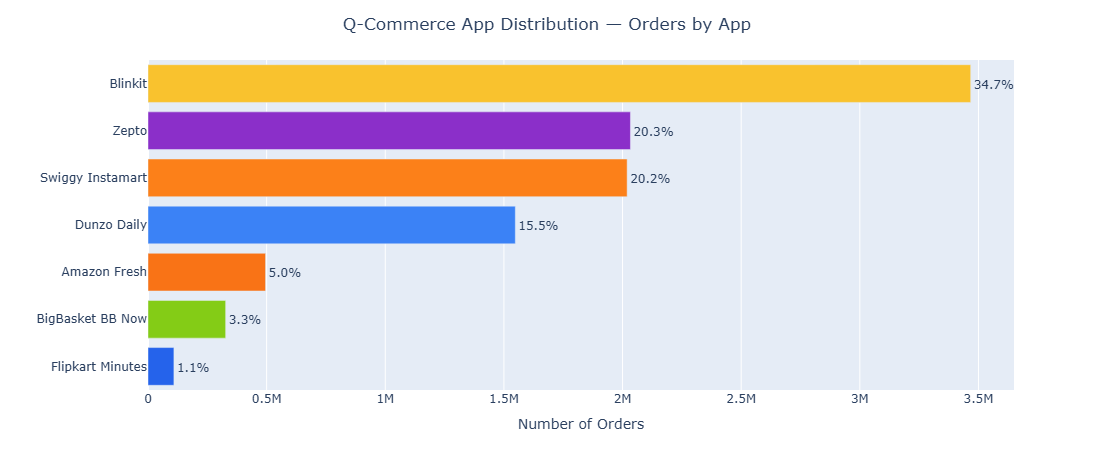

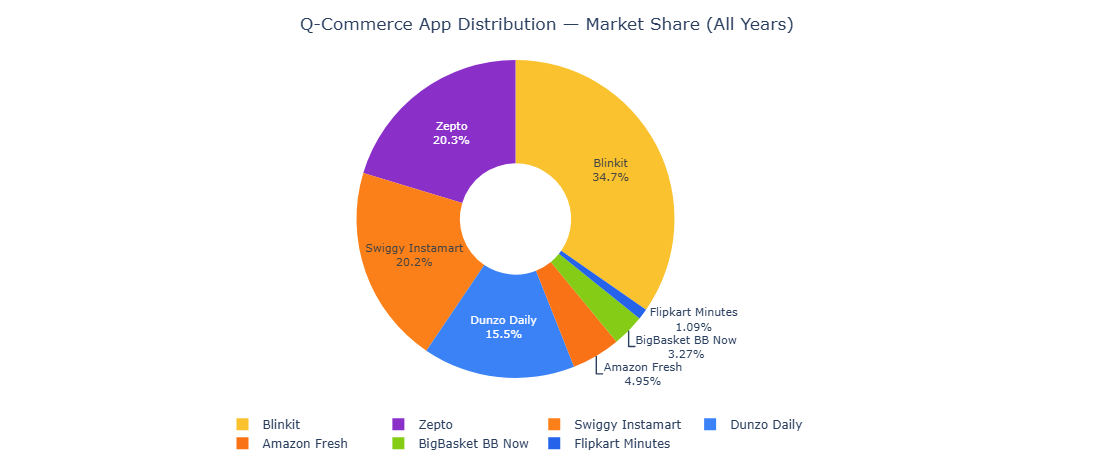

                app    count   pct
0           Blinkit  3467280  34.7
1             Zepto  2033241  20.3
2  Swiggy Instamart  2019369  20.2
3       Dunzo Daily  1548135  15.5
4      Amazon Fresh   495469   5.0
5  BigBasket BB Now   327320   3.3
6  Flipkart Minutes   109186   1.1


In [22]:
# CHART 4.2 — APP DISTRIBUTION

# Count orders per app
app_cnt = df['app'].value_counts().reset_index()
app_cnt.columns = ['app', 'count']

# Calculate each app's percentage share of total orders
total = app_cnt['count'].sum()
app_cnt['pct']       = (app_cnt['count'] / total * 100).round(1)
app_cnt['pct_label'] = app_cnt['pct'].astype(str) + '%'

# Horizontal Bar Chart 
fig_bar = px.bar(
    app_cnt,
    x                  = 'count',
    y                  = 'app',
    orientation        = 'h',
    color              = 'app',
    color_discrete_map = APP_COLORS,     # ← fixed
    text               = 'pct_label'
)

fig_bar.update_layout(
    yaxis       = dict(categoryorder='total ascending'),
    showlegend  = False,
    xaxis_title = 'Number of Orders',
    yaxis_title = '',
    height      = 470,
    title       = dict(
        text    = 'Q-Commerce App Distribution — Orders by App',
        x       = 0.5,
        xanchor = 'center'
    )
)

fig_bar.update_traces(textposition='outside')
fig_bar.show()

# Donut Pie Chart
fig_pie = px.pie(
    app_cnt,
    names              = 'app',
    values             = 'count',
    color              = 'app',
    color_discrete_map = APP_COLORS,     # ← fixed
    hole               = 0.35
)

fig_pie.update_traces(textinfo='label+percent', textfont_size=11)

fig_pie.update_layout(
    legend = dict(
        orientation = 'h',
        yanchor     = 'top',
        y           = -0.1,
        xanchor     = 'center',
        x           = 0.5
    ),
    title  = dict(
        text    = 'Q-Commerce App Distribution — Market Share (All Years)',
        x       = 0.5,
        xanchor = 'center'
    ),
    height = 470
)

fig_pie.show()

print(app_cnt[['app', 'count', 'pct']])

## Insights:
- **Blinkit emerged as the market leader**, capturing **34.7%** of total orders, driven by rapid dark-store expansion and strong operational efficiency.
- **Zepto (20.3%) and Swiggy Instamart (20.2%)** established themselves as major competitors, making the market highly competitive among the top three players.
- **The top three platforms account for over 75% of total orders**, indicating a highly concentrated Q-commerce market.
- **Dunzo, once an early pioneer in Indian Q-commerce, experienced a steady decline and its market presence collapsed to nearly 0% by 2025**, reflecting its inability to compete with aggressively expanding rivals.
- **Amazon Fresh, BigBasket BB Now, and Flipkart Minutes** collectively hold a relatively small market share, indicating that the market remains dominated by specialized Q-commerce platforms.
- **The analysis highlights the rapid evolution of India's Q-commerce industry**, where continuous expansion, faster delivery networks, and investment in dark stores played a crucial role in determining market leadership.

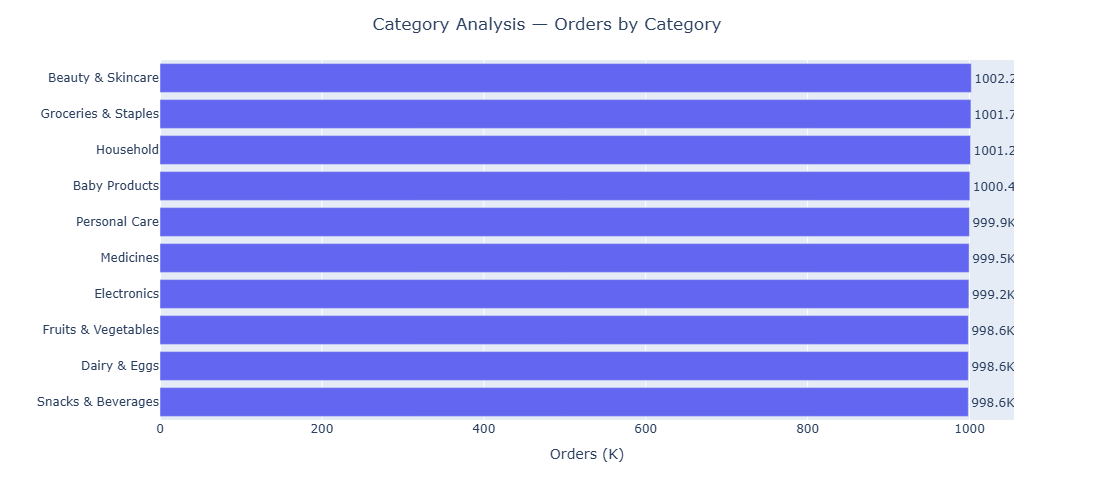

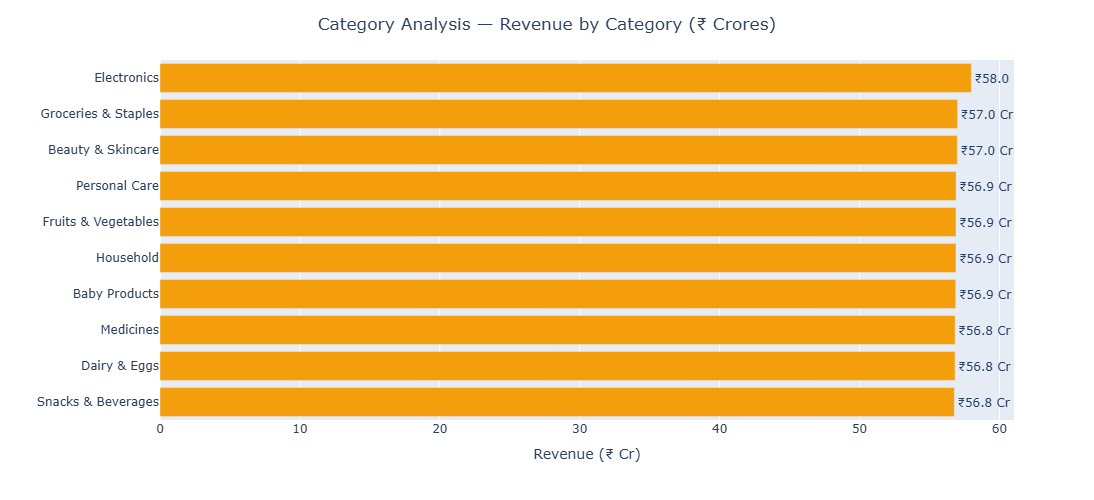

In [23]:
# CHART 4.3 — CATEGORY DISTRIBUTION

# Count total orders per category
cat_cnt = df['category'].value_counts().reset_index()
cat_cnt.columns = ['category', 'orders']

# Convert raw count to thousands for cleaner axis labels
# e.g. 4500 → 4.5 → "4.5K"
cat_cnt['orders_k'] = cat_cnt['orders'] / 1000
cat_cnt['label']    = cat_cnt['orders_k'].round(1).astype(str) + 'K'

# Revenue calculation (delivered orders only) 
delivered = df[df['order_status'] == 'Delivered']

# Sum final_amount_rs per category
cat_rev = delivered.groupby('category')['final_amount_rs'].sum()
cat_rev = cat_rev.sort_values(ascending=False).reset_index()
cat_rev.columns = ['category', 'revenue']

# Convert raw rupees to crores for readable labels
# 1 Crore = 10,000,000 rupees
# e.g. ₹45,000,000 → 4.5 → "₹4.5 Cr"
cat_rev['revenue_cr'] = cat_rev['revenue'] / 10_000_000
cat_rev['label']      = '₹' + cat_rev['revenue_cr'].round(1).astype(str) + ' Cr'

# Bar Chart 1 — Orders by Category
fig1 = px.bar(
    cat_cnt,
    x          = 'orders_k',
    y          = 'category',
    orientation = 'h',
    text       = 'label',
    color_discrete_sequence = ['#6366F1']
)

fig1.update_traces(textposition='outside')
fig1.update_layout(
    yaxis      = dict(categoryorder='total ascending'),  # Largest bar at bottom
    xaxis_title = 'Orders (K)',
    yaxis_title = '',
    showlegend  = False,
    title   = dict(
        text    = 'Category Analysis — Orders by Category',
        x       = 0.5,
        xanchor = 'center'
    ),
    height      = 500
)
fig1.show()

# Bar Chart 2 — Revenue by Category
fig2 = px.bar(
    cat_rev,
    x           = 'revenue_cr',
    y           = 'category',
    orientation = 'h',
    text        = 'label',
    color_discrete_sequence = ['#F59E0B']
)

fig2.update_traces(textposition='outside')
fig2.update_layout(
    yaxis       = dict(categoryorder='total ascending'),
    xaxis_title = 'Revenue (₹ Cr)',
    yaxis_title = '',
    showlegend  = False,
    title   = dict(
        text    = 'Category Analysis — Revenue by Category (₹ Crores)',
        x       = 0.5,
        xanchor = 'center'
    ),
    height      = 500
)
fig2.show()

## Insights:
- **Electronics generated the highest revenue (₹58.0 Cr)**, followed closely by **Groceries & Staples** and **Beauty & Skincare** (₹57.0 Cr each), indicating strong demand across multiple product categories.
- **Order volumes remained highly balanced**, with every category processing approximately **1 million orders**, suggesting diversified customer purchasing behavior rather than dependence on a single category.
- **Revenue variation across categories was minimal** (₹56.8–₹58.0 Cr), reflecting a well-distributed product portfolio and consistent spending patterns.
- **Daily essentials** such as Groceries, Dairy & Eggs, Fruits & Vegetables, and Medicines contributed significantly to total orders, reinforcing their importance in the quick-commerce ecosystem.
- **Non-essential categories** like Electronics and Beauty & Skincare generated revenue comparable to essential products, indicating that customers increasingly rely on Q-commerce platforms for both urgent and discretionary purchases.
- **The balanced distribution of orders and revenue reduces business dependency on a single product category**, making the platform more resilient to changes in customer demand.

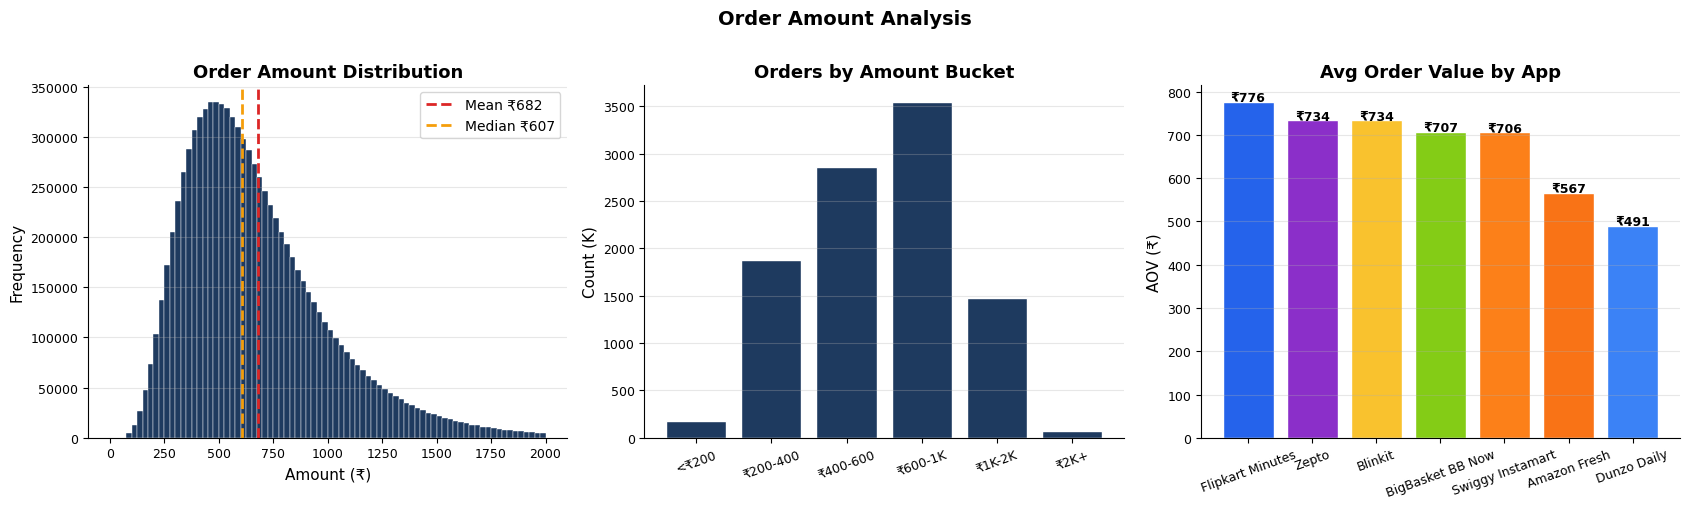

In [24]:
# CHART 4.4 — AOV & ORDER AMOUNT DISTRIBUTION

# Use only delivered orders
del_df = df[df["order_status"] == "Delivered"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Chart 1 — order amount distribution
axes[0].hist(del_df["order_amount_rs"], bins=80, color=COLORS["primary"],  # Dark navy
             edgecolor="white", linewidth=0.3, range=(0, 2000))

mean_val   = del_df["order_amount_rs"].mean()
median_val = del_df["order_amount_rs"].median()

axes[0].axvline(mean_val,   color=COLORS["cancelled"], linewidth=2,        # Red
                linestyle="--", label=f"Mean ₹{mean_val:.0f}")
axes[0].axvline(median_val, color=COLORS["festive"],   linewidth=2,        # Amber
                linestyle="--", label=f"Median ₹{median_val:.0f}")

axes[0].set_title("Order Amount Distribution")
axes[0].set_xlabel("Amount (₹)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Chart 2 — orders by price bucket
bkt = df["order_bucket"].value_counts().sort_index()

axes[1].bar(bkt.index, bkt.values / 1000, color=COLORS["primary"],        # Dark navy
            edgecolor="white")

axes[1].set_title("Orders by Amount Bucket")
axes[1].set_ylabel("Count (K)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

# Chart 3 — AOV by app
aov_app = del_df.groupby("app")["order_amount_rs"].mean().sort_values(ascending=False)
colors  = [APP_COLORS.get(app, "#94A3B8") for app in aov_app.index]
bars    = axes[2].bar(aov_app.index, aov_app.values, color=colors, edgecolor="white")

for bar, value in zip(bars, aov_app.values):
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height() + 2
    axes[2].text(x_pos, y_pos, f"₹{value:.0f}",
                 ha="center", fontsize=9, fontweight="bold")

axes[2].set_title("Avg Order Value by App")
axes[2].set_ylabel("AOV (₹)")
axes[2].tick_params(axis="x", rotation=20)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Order Amount Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Insights:
- **The average order value (AOV) is ₹682**, while the **median order value is ₹607**, indicating a right-skewed distribution with a small proportion of high-value orders increasing the overall average.
- **Most customer orders fall within the ₹600–₹1,000 range**, making it the primary revenue-generating order bucket for the platform.
- **Orders above ₹2,000 are relatively rare**, suggesting that Q-commerce is predominantly used for small to medium-sized purchases rather than bulk shopping.
- **Flipkart Minutes records the highest Average Order Value (₹776)**, followed by **Zepto (₹734)** and **Blinkit (₹734)**, indicating higher customer spending per transaction on these platforms.
- **Dunzo Daily has the lowest Average Order Value (₹491)**, reflecting comparatively smaller basket sizes than competing platforms.
- **The order value distribution highlights consistent customer spending behavior**, with the majority of purchases concentrated in mid-value baskets while high-value transactions contribute disproportionately to overall revenue.

## Phase 5 — Time Series & Growth Analysis

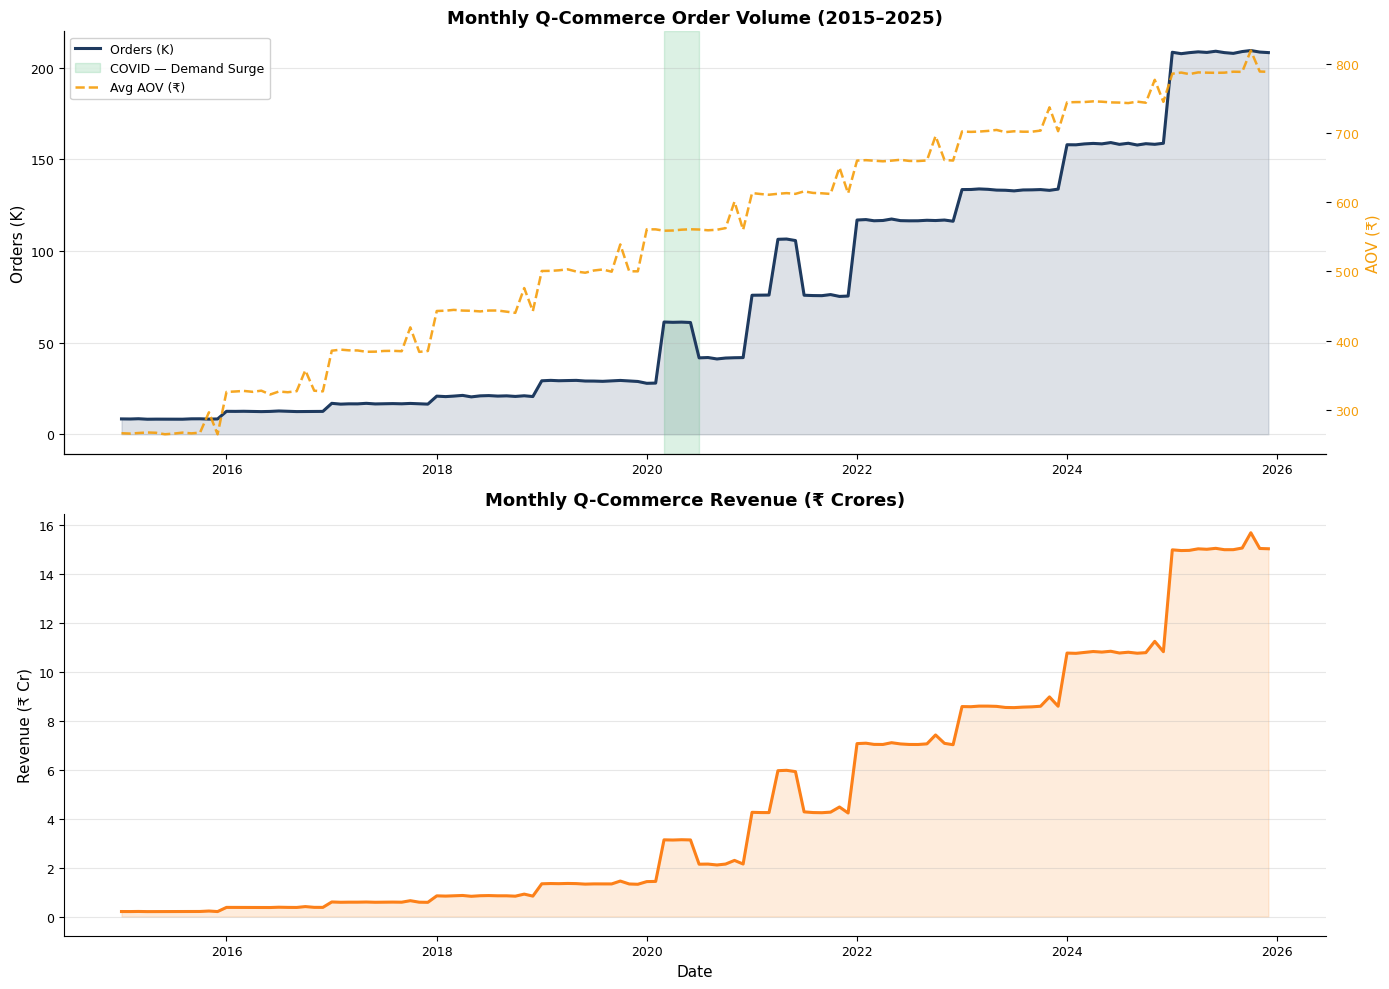

In [25]:
# CHART 5.1 — MONTHLY TREND

# Aggregate monthly metrics
monthly = df.groupby(["year", "month"]).agg(
    order_count  = ("order_id",          "count"),
    total_rev    = ("final_amount_rs",   "sum"),
    avg_aov      = ("order_amount_rs",   "mean"),
    avg_del_time = ("delivery_time_min", "mean")
).reset_index()

# Build proper date column
monthly["date"] = pd.to_datetime({
    "year"  : monthly["year"],
    "month" : monthly["month"],
    "day"   : 1
})

monthly               = monthly.sort_values("date")
monthly["orders_k"]   = monthly["order_count"] / 1_000
monthly["revenue_cr"] = monthly["total_rev"]   / 10_000_000

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Chart 1 top — order volume + AOV
axes[0].plot(monthly["date"], monthly["orders_k"],
             color=COLORS["primary"], linewidth=2.2, label="Orders (K)")  # Dark navy
axes[0].fill_between(monthly["date"], monthly["orders_k"],
                     alpha=0.15, color=COLORS["primary"])

# COVID demand surge band
axes[0].axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2020-06-30"),
    alpha=0.15, color=COLORS["delivered"], label="COVID — Demand Surge"   # Green
)

axes[0].set_title("Monthly Q-Commerce Order Volume (2015–2025)")
axes[0].set_ylabel("Orders (K)")
axes[0].grid(axis="y", alpha=0.3)

# AOV on right y-axis
ax2 = axes[0].twinx()
ax2.plot(monthly["date"], monthly["avg_aov"], "--",
         color=COLORS["festive"], linewidth=1.8, label="Avg AOV (₹)", alpha=0.9)  # Amber
ax2.set_ylabel("AOV (₹)", color=COLORS["festive"])
ax2.tick_params(axis="y", labelcolor=COLORS["festive"])

# Merge both legends into one
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2,
               loc="upper left", fontsize=9, framealpha=0.9)

# Chart 2 bottom — revenue
axes[1].plot(monthly["date"], monthly["revenue_cr"],
             color=COLORS["instamart"], linewidth=2.2)                    # Orange
axes[1].fill_between(monthly["date"], monthly["revenue_cr"],
                     alpha=0.15, color=COLORS["instamart"])

axes[1].set_title("Monthly Q-Commerce Revenue (₹ Crores)")
axes[1].set_ylabel("Revenue (₹ Cr)")
axes[1].set_xlabel("Date")
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Insights:
- **Monthly order volume increased from fewer than 10K orders in 2015 to over 200K orders by 2025**, highlighting the rapid growth of India's Q-commerce industry.
- **A significant demand surge occurred during the COVID-19 lockdown (Mar–Jun 2020)**, accelerating customer adoption and permanently increasing order volumes in subsequent years.
- **Average Order Value (AOV) increased steadily from approximately ₹270 to over ₹800**, indicating higher customer spending and larger basket sizes over time.
- **Monthly revenue grew from less than ₹0.5 Cr in 2015 to approximately ₹15 Cr by 2025**, driven by both higher order volumes and increasing average order values.
- **Post-2021, order volume and revenue maintained a consistent upward trajectory**, reflecting rapid dark-store expansion, improved delivery infrastructure, and increasing consumer dependence on quick-commerce platforms.
- **The strong correlation between order growth, rising AOV, and revenue demonstrates sustained business expansion rather than short-term seasonal fluctuations.**

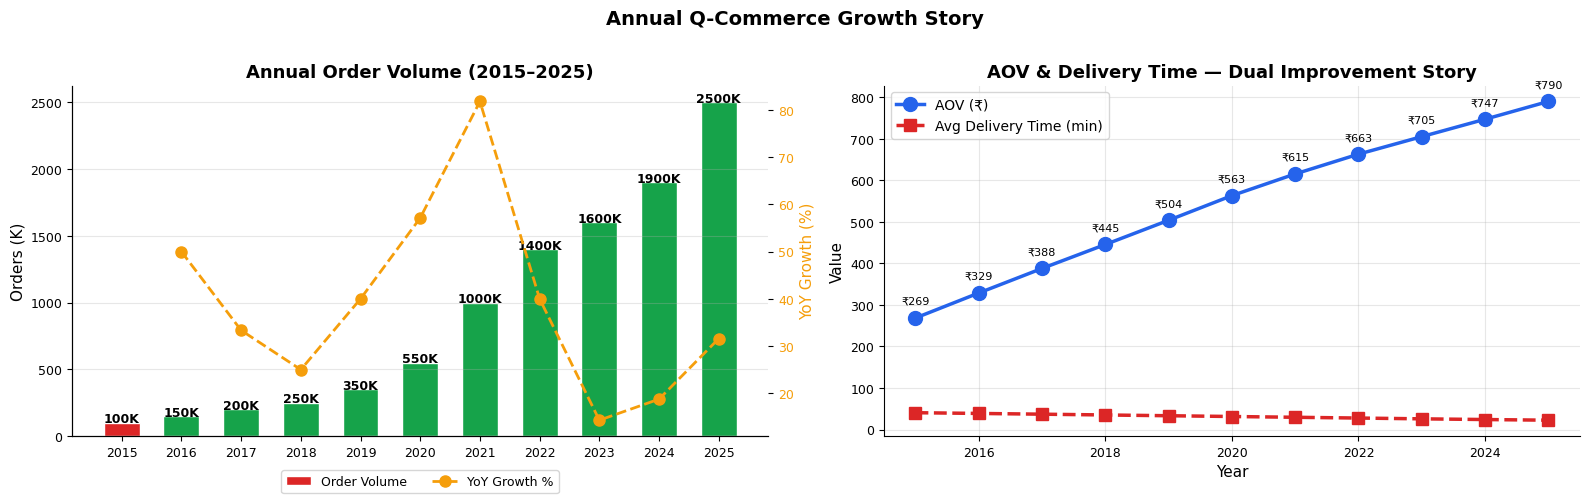

 year  order_count  yoy_growth    avg_aov   avg_del
 2015       100000         NaN 268.599101 40.543320
 2016       150000   50.000000 328.740865 38.760372
 2017       200000   33.333333 387.858119 36.971395
 2018       250000   25.000000 445.479492 35.070006
 2019       350000   40.000000 503.810045 33.243123
 2020       550000   57.142857 563.141357 31.384090
 2021      1000000   81.818182 615.335595 29.517786
 2022      1400000   40.000000 662.934509 27.659170
 2023      1600000   14.285714 705.112503 25.769822
 2024      1900000   18.750000 747.015777 24.085120
 2025      2500000   31.578947 789.796839 22.484297


In [26]:
# CHART 5.2 — ANNUAL YoY GROWTH

# Aggregate annual metrics
annual = df.groupby("year").agg(
    order_count = ("order_id",          "count"),
    total_rev   = ("final_amount_rs",   "sum"),
    avg_aov     = ("order_amount_rs",   "mean"),
    avg_del     = ("delivery_time_min", "mean")
).reset_index()

annual["yoy_growth"] = annual["order_count"].pct_change() * 100
annual["rev_growth"] = annual["total_rev"].pct_change()   * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Green bar = growth year, Red bar = decline year
colors = []
for value in annual["yoy_growth"].fillna(0):
    if value > 0:
        colors.append(COLORS["delivered"])   # Green
    else:
        colors.append(COLORS["cancelled"])   # Red

bars = axes[0].bar(
    annual["year"].astype(str),
    annual["order_count"] / 1000,
    color     = colors,
    width     = 0.6,
    edgecolor = "white",
    label     = "Order Volume"
)

# Add count label on top of every bar
for i in range(len(bars)):
    bar   = bars[i]
    count = annual["order_count"].iloc[i]
    x     = bar.get_x() + bar.get_width() / 2
    y     = bar.get_height() + 1
    axes[0].text(x, y, f"{count/1000:.0f}K",
                 ha="center", fontsize=9, fontweight="bold")

axes[0].set_title("Annual Order Volume (2015–2025)")
axes[0].set_ylabel("Orders (K)")
axes[0].grid(axis="y", alpha=0.3)

# YoY growth line on right y-axis
ax2 = axes[0].twinx()
ax2.plot(range(len(annual)), annual["yoy_growth"],
         "o--", color=COLORS["festive"], linewidth=2, markersize=8,      # Amber
         label="YoY Growth %")
ax2.set_ylabel("YoY Growth (%)", color=COLORS["festive"])
ax2.tick_params(axis="y", labelcolor=COLORS["festive"])

# Merge both legends
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
axes[0].legend(lines_1 + lines_2, labels_1 + labels_2,
               loc="lower center", bbox_to_anchor=(0.5, -0.18),
               ncol=2, fontsize=9)

# AOV and delivery time trend
axes[1].plot(annual["year"], annual["avg_aov"], "o-",
             color=COLORS["tier2"], linewidth=2.5, markersize=10,        # Medium blue
             label="AOV (₹)")

axes[1].plot(annual["year"], annual["avg_del"], "s--",
             color=COLORS["cancelled"], linewidth=2.5, markersize=8,     # Red
             label="Avg Delivery Time (min)")

for i in range(len(annual)):
    row = annual.iloc[i]
    axes[1].annotate(
        f"₹{row['avg_aov']:.0f}",
        xy         = (row["year"], row["avg_aov"]),
        xytext     = (0, 10),
        textcoords = "offset points",
        ha         = "center",
        fontsize   = 8
    )

axes[1].set_title("AOV & Delivery Time — Dual Improvement Story")
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Annual Q-Commerce Growth Story",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(annual[["year", "order_count", "yoy_growth", "avg_aov", "avg_del"]].to_string(index=False))

## Insights:
- **Annual order volume grew 25×**, increasing from **100K orders in 2015** to **2.5 million orders in 2025**, demonstrating the rapid expansion of India's Q-commerce market.
- **2021 recorded the highest YoY growth (81.8%)**, driven by the post-COVID acceleration, aggressive dark-store expansion, and entry of major quick-commerce players.
- **Average Order Value (AOV) increased steadily from ₹269 to ₹790**, indicating higher customer spending and improved revenue generation per transaction.
- **Average delivery time decreased from 40.5 minutes to 22.5 minutes**, reflecting significant improvements in logistics efficiency and last-mile delivery operations.
- **Although YoY growth moderated after 2021, total order volume continued to rise consistently**, highlighting the transition from rapid adoption to sustainable long-term growth.
- **The simultaneous increase in AOV and reduction in delivery time demonstrates operational maturity**, where platforms successfully improved customer experience while scaling business operations.

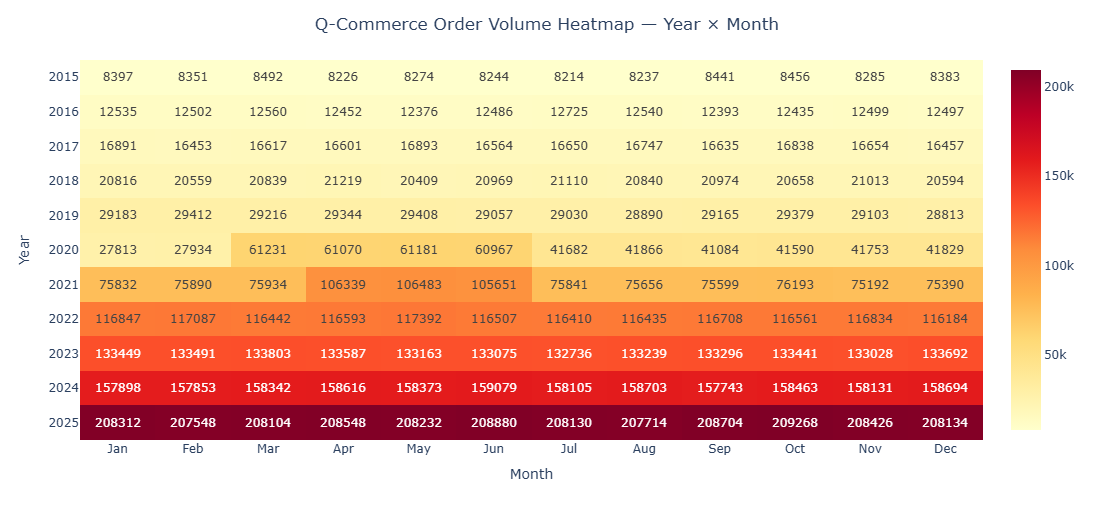

In [27]:
# CHART 5.3 — SEASONALITY HEATMAP
# Reshape data — rows = years, columns = months
pivot         = monthly.pivot(index="year", columns="month", values="order_count")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig = px.imshow(
    pivot,
    text_auto              = ".0f",
    color_continuous_scale = "YlOrRd",   # Yellow to red
    template               = "plotly_white",
    aspect                 = "auto"
)

fig.update_layout(
    height      = 520,
    xaxis_title = "Month",
    yaxis_title = "Year",
    yaxis       = dict(type="category"),
    title       = dict(
        text    = "Q-Commerce Order Volume Heatmap — Year × Month",
        x       = 0.5,
        xanchor = "center"
    )
)

fig.show()

## Insights:
- **Monthly order volumes increased consistently from 2015 to 2025**, growing from approximately **8K orders/month** in 2015 to over **208K orders/month** in 2025, demonstrating the rapid expansion of India's Q-commerce industry.
- **A noticeable spike occurred during March–June 2020**, reflecting the surge in demand during the COVID-19 lockdown when consumers increasingly relied on online grocery and essential deliveries.
- **Following the pandemic, monthly order volumes established a higher baseline**, indicating that customer adoption of quick-commerce remained strong even after restrictions were lifted.
- **2021 marked the beginning of large-scale market expansion**, with sustained increases across all months driven by dark-store growth and the entry of major Q-commerce players.
- **2025 recorded the highest monthly order volumes across the entire analysis period**, with every month exceeding **200K orders**, highlighting the maturity and widespread adoption of the Q-commerce ecosystem.
- **The relatively uniform color intensity within each year indicates stable demand throughout the year**, while the significant increase across years reflects long-term market growth rather than short-term seasonal fluctuations.

## Phase 6 — App-wise Market Share Evolution

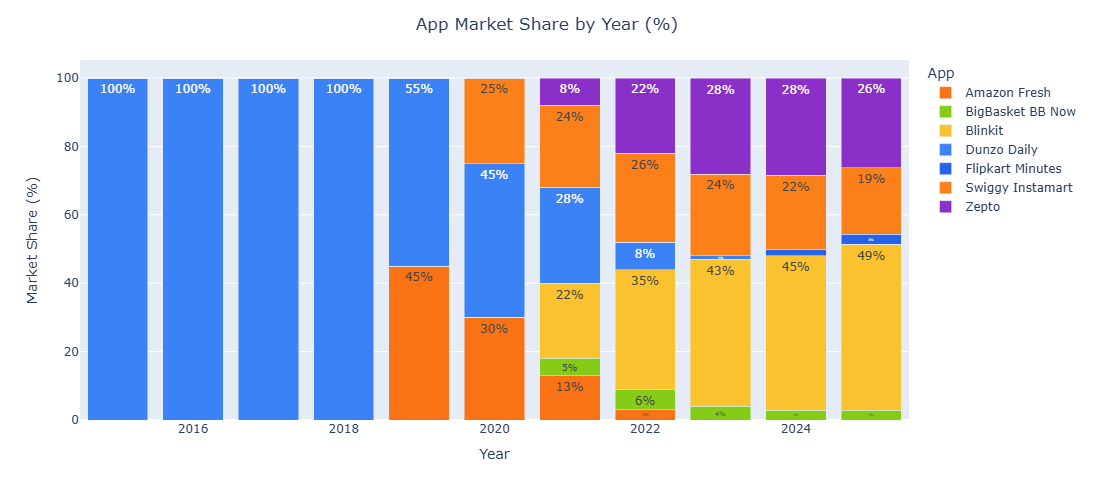

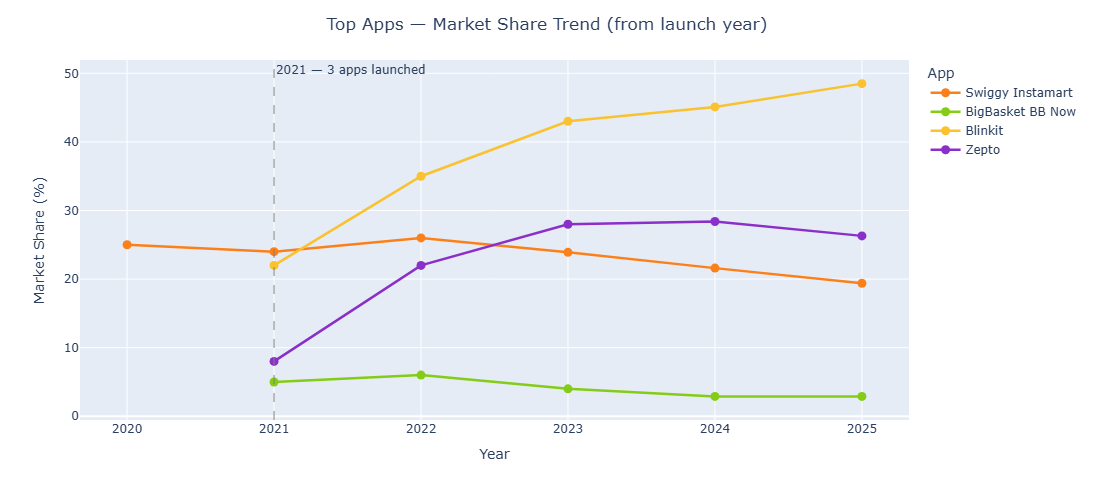

In [28]:
# CHART 6.1 — APP MARKET SHARE BY YEAR (Plotly Version)

# Count orders per year + app
app_yr         = df.groupby(["year", "app"]).size().reset_index()
app_yr.columns = ["year", "app", "order_count"]

# Total orders per year
yearly_total         = df.groupby("year")["order_id"].count().reset_index()
yearly_total.columns = ["year", "total_orders"]

# Merge and calculate share %
app_yr              = app_yr.merge(yearly_total, on="year")
app_yr["share_pct"] = (app_yr["order_count"] / app_yr["total_orders"] * 100).round(1)

# Stacked bar chart
fig1 = px.bar(
    app_yr,
    x                  = "year",
    y                  = "share_pct",
    color              = "app",
    barmode            = "stack",
    text               = "share_pct",
    color_discrete_map = APP_COLORS,
)

fig1.update_traces(texttemplate="%{text:.0f}%", textposition="inside")
fig1.update_layout(
    xaxis_title = "Year",
    yaxis_title = "Market Share (%)",
    height      = 500,
    title       = dict(
        text    = "App Market Share by Year (%)",
        x       = 0.5,
        xanchor = "center"
    ),
    legend = dict(title="App")
)
fig1.show()

# Top 4 apps line chart
top_apps = ["Blinkit", "Swiggy Instamart", "Zepto", "BigBasket BB Now"]
top_df   = app_yr[app_yr["app"].isin(top_apps)]
top_df   = top_df[top_df["share_pct"] > 0]

fig2 = px.line(
    top_df,
    x                  = "year",
    y                  = "share_pct",
    color              = "app",
    markers            = True,
    color_discrete_map = APP_COLORS,
)

fig2.update_traces(line_width=2.5, marker_size=9)

# Vertical line marks 2021 — year Blinkit, Zepto and BB Now launched
fig2.add_vline(
    x               = 2021,
    line_dash       = "dash",
    line_color      = "gray",
    line_width      = 1,
    annotation_text = "2021 — 3 apps launched"
)

fig2.update_layout(
    xaxis_title = "Year",
    yaxis_title = "Market Share (%)",
    height      = 500,
    title       = dict(
        text    = "Top Apps — Market Share Trend (from launch year)",
        x       = 0.5,
        xanchor = "center"
    ),
    legend = dict(title="App")
)
fig2.show()

## Insights:
- **Dunzo dominated the market from 2015–2018**, operating as the only major Q-commerce platform before new competitors entered the industry.
- **The market became highly competitive after 2021**, with the launch and rapid expansion of **Blinkit, Zepto, and BigBasket BB Now**, fundamentally reshaping the competitive landscape.
- **Blinkit emerged as the clear market leader**, increasing its market share from **22% in 2021 to nearly 49% by 2025**, driven by aggressive dark-store expansion and faster delivery capabilities.
- **Zepto experienced the fastest growth**, expanding from **8% market share in 2021 to 26% in 2025**, establishing itself as one of the leading quick-commerce platforms.
- **Swiggy Instamart maintained a strong market presence** but gradually declined from **30% in 2020 to 19% in 2025** as competition intensified.
- **Dunzo's market share declined dramatically after 2020**, reflecting its inability to compete with rapidly expanding rivals and its eventual collapse in the Indian Q-commerce market.
- **By 2025, Blinkit and Zepto together controlled approximately 75% of the market**, highlighting significant market consolidation among the leading Q-commerce players.

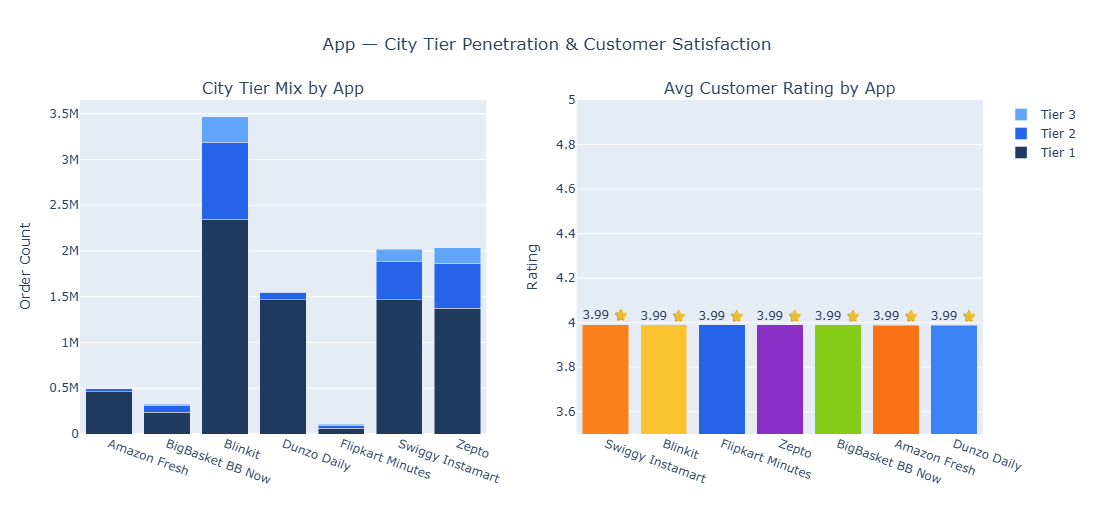

In [29]:
# CHART 6.2 — APP vs CITY TIER & CUSTOMER RATING

# Count orders per app + city tier
app_tier  = df.groupby(["app", "city_tier"]).size().reset_index(name="count")

# Tier colours from COLORS dict
tier_colors = {
    "Tier 1" : COLORS["tier1"],   # Dark navy
    "Tier 2" : COLORS["tier2"],   # Medium blue
    "Tier 3" : COLORS["tier3"],   # Light blue
}

all_tiers = app_tier["city_tier"].unique()

# Average rating per app
app_rating         = df.groupby("app")["customer_rating"].mean()
app_rating         = app_rating.sort_values(ascending=False).reset_index()
app_rating.columns = ["app", "avg_rating"]

rating_colors = [APP_COLORS.get(app, "#94A3B8") for app in app_rating["app"]]

fig = make_subplots(
    rows           = 1, cols = 2,
    subplot_titles = ["City Tier Mix by App", "Avg Customer Rating by App"]
)

# Stacked bar — city tier
for tier in all_tiers:
    tier_data = app_tier[app_tier["city_tier"] == tier]
    fig.add_trace(
        go.Bar(
            x            = tier_data["app"],
            y            = tier_data["count"],
            name         = str(tier),
            marker_color = tier_colors.get(str(tier), "#94A3B8")
        ),
        row=1, col=1
    )

# Bar — avg rating
fig.add_trace(
    go.Bar(
        x            = app_rating["app"],
        y            = app_rating["avg_rating"],
        marker_color = rating_colors,
        text         = app_rating["avg_rating"].round(2).astype(str) + " ⭐",
        textposition = "outside",
        showlegend   = False
    ),
    row=1, col=2
)

fig.update_layout(
    barmode = "stack",
    title   = dict(
        text    = "App — City Tier Penetration & Customer Satisfaction",
        x       = 0.5,
        xanchor = "center"
    ),
    height  = 500,
    width   = 1100
)

fig.update_xaxes(tickangle=20, row=1, col=1)
fig.update_xaxes(tickangle=20, row=1, col=2)
fig.update_yaxes(title_text="Order Count",              row=1, col=1)
fig.update_yaxes(title_text="Rating", range=[3.5, 5.0], row=1, col=2)

fig.show()

## Insights:
- **Blinkit processed the highest number of orders across all city tiers**, reflecting its extensive dark-store network and strong nationwide presence.
- **Tier 1 cities contributed the largest share of orders for every platform**, while **Tier 2 and Tier 3 adoption increased steadily**, highlighting the expansion of Q-commerce beyond metropolitan areas.
- **Zepto and Swiggy Instamart demonstrated strong penetration in Tier 2 cities**, indicating successful expansion into emerging urban markets.
- **Amazon Fresh, BigBasket BB Now, and Flipkart Minutes maintained comparatively smaller order volumes**, suggesting a more limited market presence than dedicated Q-commerce platforms.
- **Average customer ratings remained highly consistent at approximately 4.0/5 across all platforms**, indicating similar levels of customer satisfaction and service quality.
- **The minimal variation in ratings suggests that competitive advantage is driven more by delivery speed, product availability, and market reach than by customer satisfaction scores alone.**

## Phase 7 — City Tier Expansion Over the Years

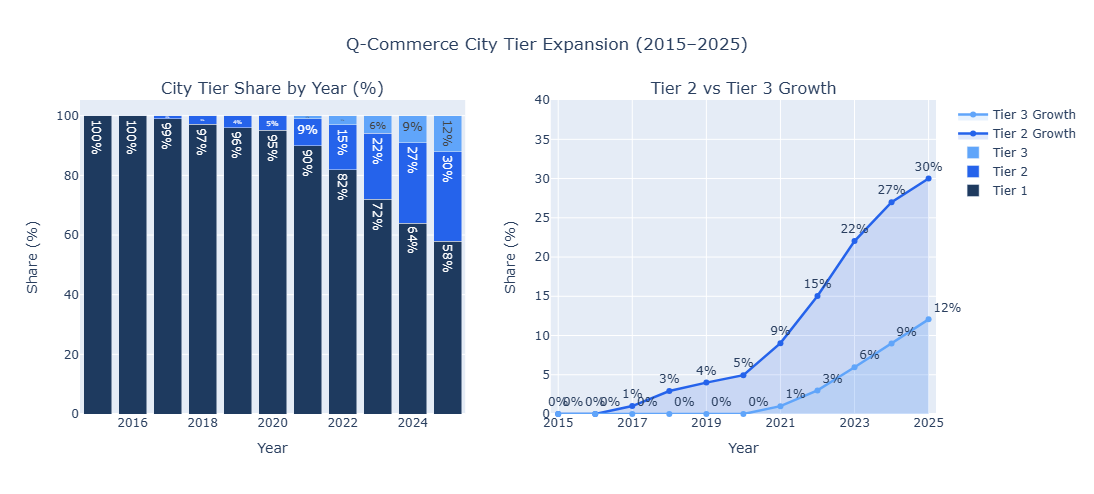

In [30]:
# CHART 7.1 — CITY TIER EXPANSION

# Count orders per year + city tier
tier_counts   = df.groupby(["year", "city_tier"]).size().reset_index(name="count")
yearly_totals = df.groupby("year").size().reset_index(name="total_orders")
tier_yr       = pd.merge(tier_counts, yearly_totals, on="year")
tier_yr["pct"] = (tier_yr["count"] / tier_yr["total_orders"] * 100).round(2)

# Separate tables per tier
tier_1 = tier_yr[tier_yr["city_tier"] == "Tier 1"]
tier_2 = tier_yr[tier_yr["city_tier"] == "Tier 2"]
tier_3 = tier_yr[tier_yr["city_tier"] == "Tier 3"]

fig = make_subplots(
    rows           = 1, cols = 2,
    subplot_titles = ["City Tier Share by Year (%)", "Tier 2 vs Tier 3 Growth"]
)

# Stacked bar — tier 1
fig.add_trace(
    go.Bar(
        x            = tier_1["year"],
        y            = tier_1["pct"],
        name         = "Tier 1",
        marker_color = COLORS["tier1"],                  # Dark navy
        text         = tier_1["pct"].round(0).astype(int).astype(str) + "%",
        textposition = "inside"
    ), row=1, col=1
)

# Stacked bar — tier 2
fig.add_trace(
    go.Bar(
        x            = tier_2["year"],
        y            = tier_2["pct"],
        name         = "Tier 2",
        marker_color = COLORS["tier2"],                  # Medium blue
        text         = tier_2["pct"].round(0).astype(int).astype(str) + "%",
        textposition = "inside"
    ), row=1, col=1
)

# Stacked bar — tier 3
fig.add_trace(
    go.Bar(
        x            = tier_3["year"],
        y            = tier_3["pct"],
        name         = "Tier 3",
        marker_color = COLORS["tier3"],                  # Light blue
        text         = tier_3["pct"].round(0).astype(int).astype(str) + "%",
        textposition = "inside"
    ), row=1, col=1
)

# Line — tier 2 growth
fig.add_trace(
    go.Scatter(
        x             = tier_2["year"],
        y             = tier_2["pct"],
        name          = "Tier 2 Growth",
        mode          = "lines+markers+text",
        line          = dict(color=COLORS["tier2"], width=2.5),           # Medium blue
        fill          = "tozeroy",
        fillcolor     = "rgba(37, 99, 235, 0.15)",
        text          = tier_2["pct"].round(0).astype(int).astype(str) + "%",
        textposition  = "top center",
        cliponaxis    = False
    ), row=1, col=2
)

# Line — tier 3 growth
fig.add_trace(
    go.Scatter(
        x             = tier_3["year"],
        y             = tier_3["pct"],
        name          = "Tier 3 Growth",
        mode          = "lines+markers+text",
        line          = dict(color=COLORS["tier3"], width=2.5),           # Light blue
        fill          = "tozeroy",
        fillcolor     = "rgba(96, 165, 250, 0.15)",
        text          = tier_3["pct"].round(0).astype(int).astype(str) + "%",
        textposition  = "top right",
        cliponaxis    = False
    ), row=1, col=2
)

fig.update_layout(
    barmode = "stack",
    title   = dict(
        text    = "Q-Commerce City Tier Expansion (2015–2025)",
        x       = 0.5,
        xanchor = "center"
    ),
    height  = 480,
    width   = 1100
)

fig.update_xaxes(range=[2014.8, 2025.2], tick0=2015, dtick=2,
                 title_text="Year", row=1, col=2)

highest_number = max(tier_2["pct"].max(), tier_3["pct"].max())
fig.update_yaxes(range=[0, highest_number + 10],
                 title_text="Share (%)", row=1, col=2)

fig.update_xaxes(title_text="Year",      dtick=2, row=1, col=1)
fig.update_yaxes(title_text="Share (%)",          row=1, col=1)

fig.show()

## Insights:
- **Tier 1 cities dominated the market from 2015–2020**, accounting for over **95% of total orders**, indicating that early Q-commerce adoption was concentrated in metropolitan cities.
- **Significant expansion into Tier 2 cities began in 2021**, with market share increasing from **5% in 2021 to 30% by 2025**, driven by rapid dark-store expansion and growing consumer demand.
- **Tier 3 cities emerged as a new growth market after 2022**, reaching **12% of total orders by 2025**, demonstrating the industry's successful penetration into smaller cities.
- **The share of Tier 1 cities declined from 100% in 2015 to 58% in 2025**, reflecting geographic diversification rather than a decline in demand.
- **2021 marked the turning point in India's Q-commerce expansion**, as platforms accelerated their presence beyond metro cities to capture emerging markets.
- **The steady growth of Tier 2 and Tier 3 markets highlights significant opportunities for future expansion**, supported by improving logistics infrastructure, dark-store networks, and increasing digital adoption.

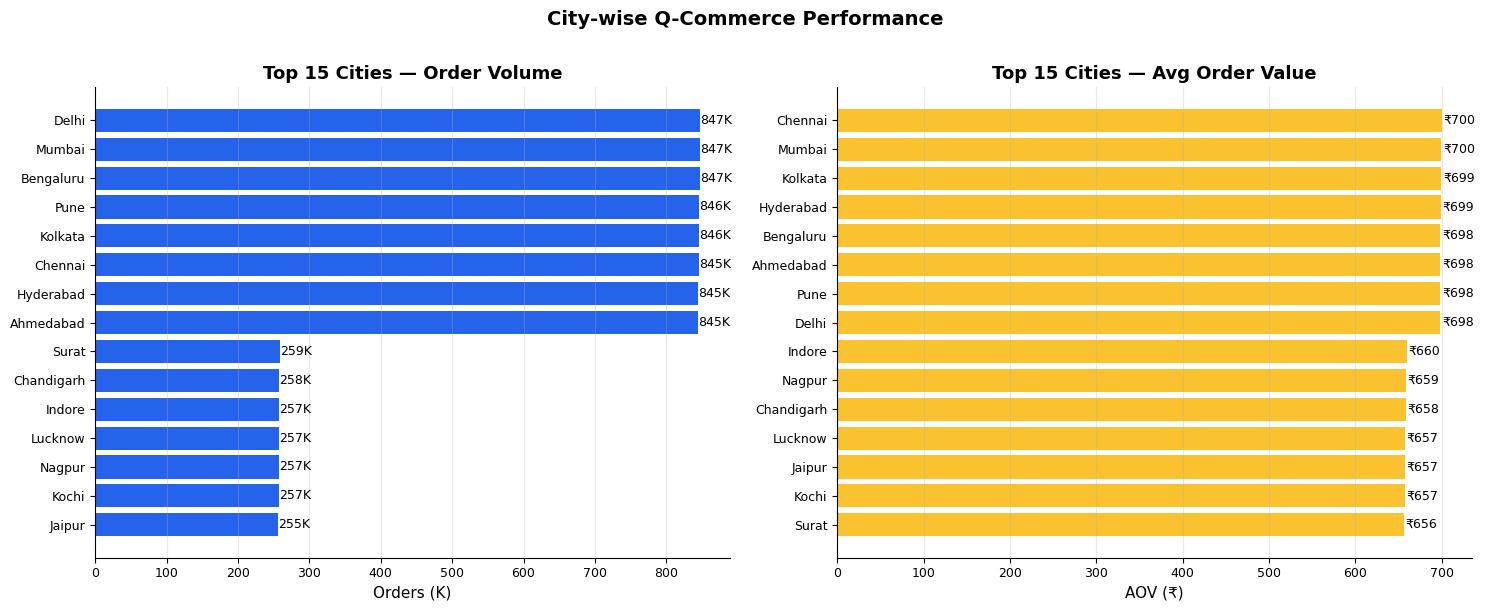

In [31]:
# CHART 7.2 — TOP CITIES BY ORDER VOLUME & AOV

# Delivered orders only
delivered_df = df[df["order_status"] == "Delivered"]

# Metrics per city
city_data = delivered_df.groupby("city").agg(
    orders  = ("order_id",        "count"),
    revenue = ("final_amount_rs", "sum"),
    avg_aov = ("order_amount_rs", "mean")
).reset_index()

# Top 15 by order volume
top15_orders = city_data.sort_values(by="orders", ascending=False).head(15)
top15_orders = top15_orders.sort_values(by="orders", ascending=True)

# Top 15 by AOV
top15_aov = city_data.sort_values(by="avg_aov", ascending=False).head(15)
top15_aov = top15_aov.sort_values(by="avg_aov", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1 — order volume
orders_in_k = top15_orders["orders"] / 1000

bars_1 = axes[0].barh(
    y     = top15_orders["city"],
    width = orders_in_k,
    color = COLORS["tier2"]        # Medium blue
)

for bar, value in zip(bars_1, orders_in_k):
    axes[0].text(
        value + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.0f}K",
        va="center", fontsize=9
    )

axes[0].set_title("Top 15 Cities — Order Volume")
axes[0].set_xlabel("Orders (K)")
axes[0].grid(axis="x", alpha=0.3)

# Chart 2 — AOV
bars_2 = axes[1].barh(
    y     = top15_aov["city"],
    width = top15_aov["avg_aov"],
    color = COLORS["blinkit"]      # Yellow
)

for bar, value in zip(bars_2, top15_aov["avg_aov"]):
    axes[1].text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f"₹{value:.0f}",
        va="center", fontsize=9
    )

axes[1].set_title("Top 15 Cities — Avg Order Value")
axes[1].set_xlabel("AOV (₹)")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("City-wise Q-Commerce Performance",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Insights:
- **Delhi, Mumbai, and Bengaluru recorded the highest order volumes**, each processing approximately **847K orders**, highlighting their dominance as India's largest Q-commerce markets.
- **Pune, Kolkata, Chennai, Hyderabad, and Ahmedabad** also contributed significantly, demonstrating strong demand across major metropolitan cities.
- **Average Order Value (AOV) remained consistent across top cities**, ranging from **₹656 to ₹700**, indicating similar customer spending patterns nationwide.
- **Chennai and Mumbai recorded the highest AOV (₹700)**, suggesting comparatively higher basket sizes than other cities.
- **Tier-1 metropolitan cities continue to drive the majority of Q-commerce demand**, supported by dense populations, higher purchasing power, and well-established dark-store infrastructure.
- **The narrow variation in AOV across cities indicates standardized customer purchasing behavior**, while differences in order volume are primarily driven by market size and customer base rather than spending per order.ents

## Phase 8 — Delivery Speed & Consumer Behaviour

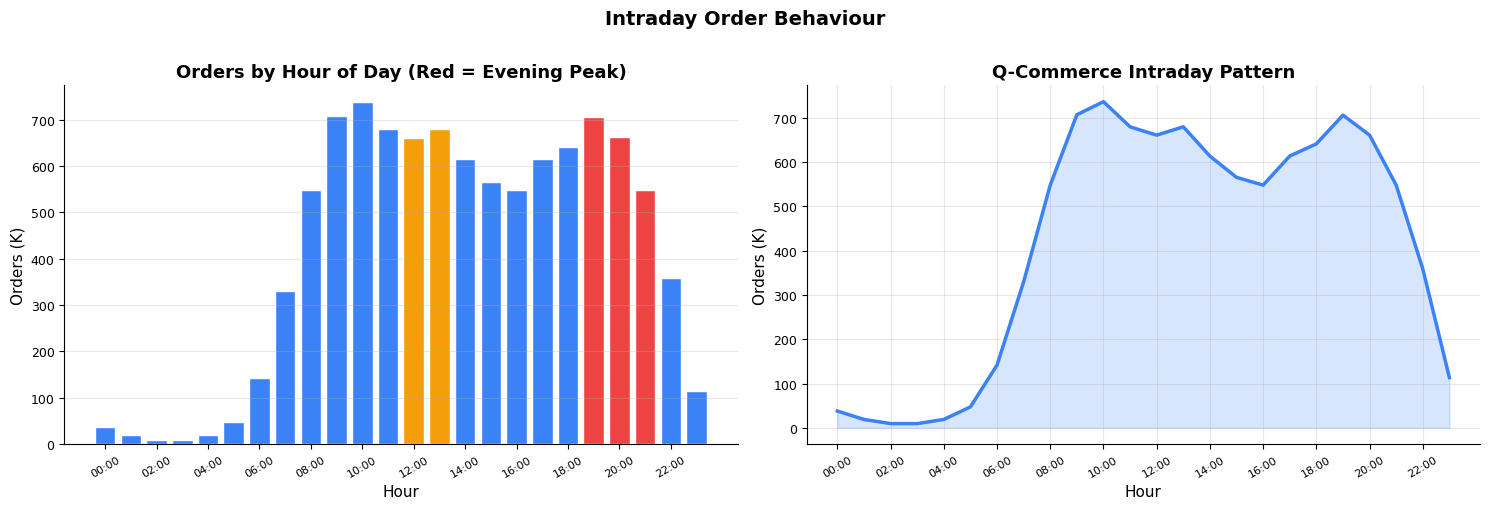

In [32]:
# CHART 8.1 — HOUR OF DAY PATTERN

# Count orders per hour
hourly             = df.groupby("hour").size().reset_index(name="count")
hourly["orders_k"] = hourly["count"] / 1000

# Evening peak = red, lunch peak = amber, normal = blue
bar_colors = []
for hour in hourly["hour"]:
    if hour in [19, 20, 21]:
        bar_colors.append("#EF4444")   # Red — evening peak
    elif hour in [12, 13]:
        bar_colors.append("#F59E0B")   # Amber — lunch peak
    else:
        bar_colors.append("#3B82F6")   # Blue — normal hours

# X-axis time labels every 2 hours
tick_positions = []
tick_labels    = []

for hour in range(0, 24, 2):
    tick_positions.append(hour)
    tick_labels.append(f"{hour:02d}:00")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1 — bar chart
axes[0].bar(
    x         = hourly["hour"],
    height    = hourly["orders_k"],
    color     = bar_colors,
    edgecolor = "white"
)

axes[0].set_title("Orders by Hour of Day (Red = Evening Peak)")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Orders (K)")
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=30, fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Chart 2 — line chart
axes[1].plot(
    hourly["hour"],
    hourly["orders_k"],
    color     = "#3B82F6",           # Blue
    linewidth = 2.5
)

axes[1].fill_between(
    hourly["hour"],
    hourly["orders_k"],
    alpha = 0.2,
    color = "#3B82F6"                # Blue
)

axes[1].set_title("Q-Commerce Intraday Pattern")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Orders (K)")
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=30, fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Intraday Order Behaviour", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Insights:
- **Order demand begins rising sharply after 7:00 AM**, reflecting customers placing orders for breakfast, groceries, and daily essentials.
- **The first major peak occurs between 9:00–11:00 AM**, when order volume exceeds **700K orders**, making it one of the busiest periods of the day.
- **Order activity remains consistently high throughout the afternoon (12:00–5:00 PM)**, indicating steady demand for groceries, medicines, and household essentials.
- **A second peak is observed during 7:00–9:00 PM**, driven by dinner-time purchases and after-work shopping, making evening the busiest ordering window.
- **Late-night (11:00 PM–5:00 AM) order volumes remain minimal**, reflecting limited customer demand during overnight hours.
- **The dual-peak ordering pattern highlights predictable customer purchasing behavior**, enabling platforms to optimize inventory allocation, delivery partner scheduling, and dark-store operations during peak demand periods.

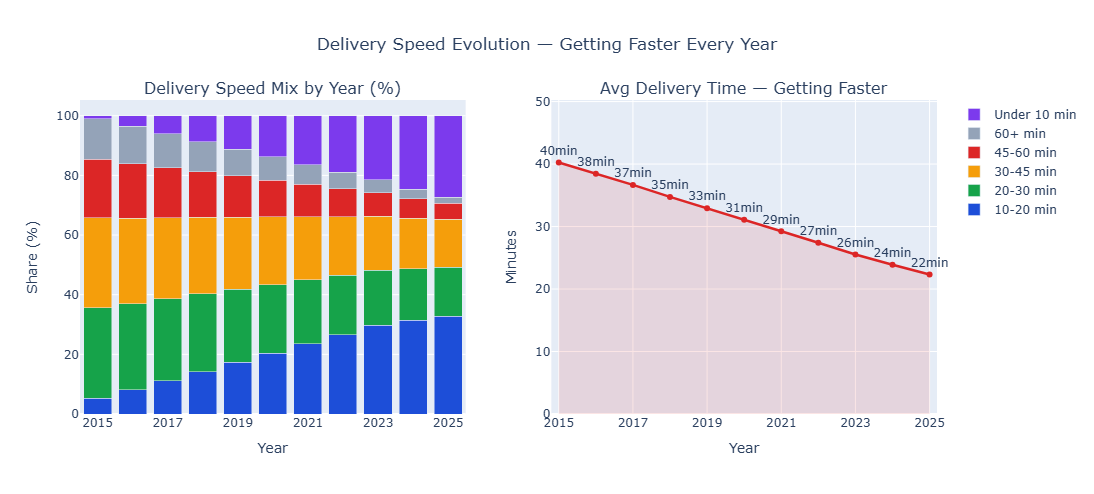

In [33]:
# CHART 8.2 — DELIVERY SPEED EVOLUTION

# Delivered orders only
delivered_df  = df[df["order_status"] == "Delivered"]
slot_counts   = delivered_df.groupby(["year", "delivery_slot"]).size().reset_index(name="count")
yearly_totals = delivered_df.groupby("year").size().reset_index(name="total_orders")
del_yr        = pd.merge(slot_counts, yearly_totals, on="year")
del_yr["pct"] = (del_yr["count"] / del_yr["total_orders"] * 100).round(2)

# Average delivery time per year
avg_del               = delivered_df.groupby("year")["delivery_time_min"].mean().reset_index()
avg_del["text_label"] = avg_del["delivery_time_min"].round(0).astype(int).astype(str) + "min"

fig = make_subplots(
    rows           = 1, cols = 2,
    subplot_titles = ["Delivery Speed Mix by Year (%)", "Avg Delivery Time — Getting Faster"]
)

# Chart-specific colours for delivery slots
speed_colors = ["#1D4ED8", "#16A34A", "#F59E0B", "#DC2626", "#94A3B8","#7C3AED"]
slots        = del_yr["delivery_slot"].unique()

for i in range(len(slots)):
    slot_name  = slots[i]
    slot_color = speed_colors[i]
    slot_data  = del_yr[del_yr["delivery_slot"] == slot_name]

    fig.add_trace(
        go.Bar(
            x            = slot_data["year"].astype(str),
            y            = slot_data["pct"],
            name         = slot_name,
            marker_color = slot_color
        ),
        row=1, col=1
    )

# Avg delivery time line
fig.add_trace(
    go.Scatter(
        x             = avg_del["year"],
        y             = avg_del["delivery_time_min"],
        name          = "Avg Del Time",
        mode          = "lines+markers+text",
        line          = dict(color="#DC2626", width=2.5),    # Red
        fill          = "tozeroy",
        fillcolor     = "rgba(220, 38, 38, 0.12)",
        text          = avg_del["text_label"],
        textposition  = "top center",
        showlegend    = False,
        cliponaxis    = False
    ),
    row=1, col=2
)

fig.update_layout(
    barmode = "stack",
    title   = dict(
        text    = "Delivery Speed Evolution — Getting Faster Every Year",
        x       = 0.5,
        xanchor = "center"
    ),
    height  = 480,
    width   = 1100
)

fig.update_xaxes(range=[2014.8, 2025.2], tickmode="linear",
                 tick0=2015, dtick=2, title_text="Year", row=1, col=2)

max_time = avg_del["delivery_time_min"].max()
fig.update_yaxes(range=[0, max_time + 10], title_text="Minutes",  row=1, col=2)
fig.update_xaxes(title_text="Year",        dtick=2,               row=1, col=1)
fig.update_yaxes(title_text="Share (%)",                          row=1, col=1)

fig.show()

## Insights:
- **Average delivery time improved significantly**, decreasing from **40 minutes in 2015** to **22 minutes in 2025**, representing a **45% reduction** in delivery time.
- **The share of fast deliveries (10–20 minutes) increased consistently** over the years, reflecting improvements in logistics, dark-store expansion, and route optimization.
- **Long delivery windows (45–60+ minutes) declined substantially**, indicating enhanced operational efficiency and better last-mile execution.
- **Ultra-fast deliveries (under 10 minutes) became increasingly common after 2020**, highlighting the industry's shift toward rapid fulfillment models.
- **Continuous improvements in delivery speed align with the rapid growth of India's Q-commerce ecosystem**, enabling platforms to meet rising customer expectations for convenience.
- **The transition from slower to faster delivery categories demonstrates the operational maturity of Q-commerce platforms**, supported by investments in dark stores, technology, and delivery infrastructure.

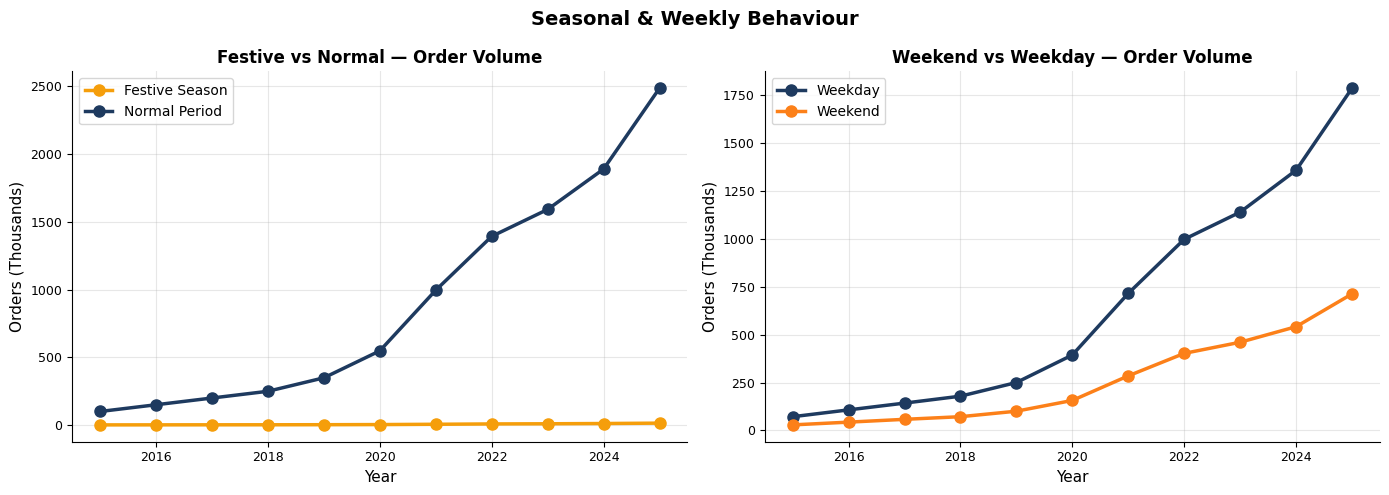

Festive vs Normal — Order Counts:
 year          label   count
 2015  Normal Period   99476
 2015 Festive Season     524
 2016  Normal Period  149190
 2016 Festive Season     810
 2017  Normal Period  198877
 2017 Festive Season    1123
 2018  Normal Period  248652
 2018 Festive Season    1348
 2019  Normal Period  348098
 2019 Festive Season    1902
 2020  Normal Period  547159
 2020 Festive Season    2841
 2021  Normal Period  994966
 2021 Festive Season    5034
 2022  Normal Period 1392413
 2022 Festive Season    7587
 2023  Normal Period 1591271
 2023 Festive Season    8729
 2024  Normal Period 1889375
 2024 Festive Season   10625
 2025  Normal Period 2486538
 2025 Festive Season   13462

Weekend vs Weekday — Order Counts:
 year   label   count
 2015 Weekday   71351
 2015 Weekend   28649
 2016 Weekday  107011
 2016 Weekend   42989
 2017 Weekday  142365
 2017 Weekend   57635
 2018 Weekday  178571
 2018 Weekend   71429
 2019 Weekday  249894
 2019 Weekend  100106
 2020 Weekday  393655

In [34]:
# CHART 8.3 — FESTIVE vs NORMAL & WEEKEND vs WEEKDAY

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Festive vs normal
fest_comp = df.groupby(["year", "is_festive_season"]).agg(
    count   = ("order_id",        "count"),
    avg_aov = ("order_amount_rs", "mean")
).reset_index()

fest_comp["label"] = fest_comp["is_festive_season"].map({
    0 : "Normal Period",
    1 : "Festive Season"
})

for label, group in fest_comp.groupby("label"):
    if label == "Festive Season":
        line_color = COLORS["festive"]   # Amber
    else:
        line_color = COLORS["primary"]   # Dark navy

    axes[0].plot(
        group["year"],
        group["count"] / 1000,
        "o-",
        label      = label,
        color      = line_color,
        linewidth  = 2.5,
        markersize = 8
    )

axes[0].set_title("Festive vs Normal — Order Volume", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Orders (Thousands)")
axes[0].set_xlabel("Year")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Weekend vs weekday
wknd = df.groupby(["year", "is_weekend"]).agg(
    count = ("order_id",        "count"),
    avg   = ("order_amount_rs", "mean")
).reset_index()

wknd["label"] = wknd["is_weekend"].map({
    0 : "Weekday",
    1 : "Weekend"
})

for label, group in wknd.groupby("label"):
    if label == "Weekend":
        line_color = COLORS["instamart"]   # Orange
    else:
        line_color = COLORS["primary"]     # Dark navy

    axes[1].plot(
        group["year"],
        group["count"] / 1000,
        "o-",
        label      = label,
        color      = line_color,
        linewidth  = 2.5,
        markersize = 8
    )

axes[1].set_title("Weekend vs Weekday — Order Volume", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Orders (Thousands)")
axes[1].set_xlabel("Year")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Seasonal & Weekly Behaviour", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Festive vs Normal — Order Counts:")
print(fest_comp[["year", "label", "count"]].to_string(index=False))
print()
print("Weekend vs Weekday — Order Counts:")
print(wknd[["year", "label", "count"]].to_string(index=False))

## Insights:
- **Overall Q-commerce demand increased dramatically between 2015 and 2025**, with both normal-period and festive-season orders growing year after year, reflecting the rapid expansion of India's quick-commerce ecosystem.
- **Normal shopping periods accounted for over 99% of total orders**, while festive-season orders remained below 1%, indicating that Q-commerce is primarily driven by everyday convenience rather than seasonal shopping events.
- **Festive-season orders increased from 524 orders in 2015 to over 13.4K in 2025**, demonstrating strong year-over-year growth despite representing a relatively small share of total transactions.
- **Weekday demand consistently exceeded weekend demand**, with approximately **71–72% of orders placed on weekdays** and **28–29% on weekends**, highlighting that customers frequently rely on Q-commerce for daily essential purchases.
- **Weekday orders grew from 71K in 2015 to 1.79M in 2025**, while **weekend orders increased from 29K to over 713K**, reflecting strong adoption across both workdays and weekends.
- **The parallel upward trend across festive, weekday, and weekend orders indicates sustained customer engagement**, suggesting that Q-commerce has evolved into an essential part of everyday shopping rather than a service used only during holidays or weekends.

## Phase 9 — Payment Mode & Discount Analysis

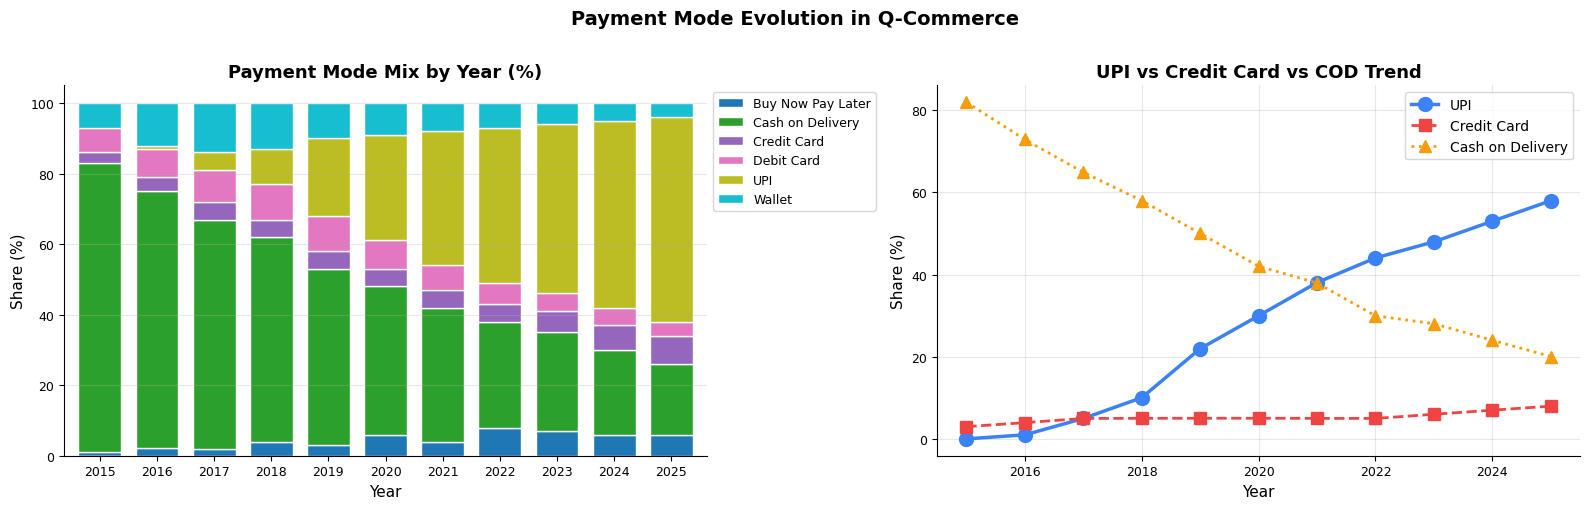

In [35]:
# CHART 9.1 — PAYMENT MODE EVOLUTION

# Count orders per year + payment mode
pay_counts    = df.groupby(["year", "payment_mode"]).size().reset_index(name="count")
yearly_totals = df.groupby("year").size().reset_index(name="total_orders")
merged_data   = pd.merge(pay_counts, yearly_totals, on="year")
merged_data["pct"] = (merged_data["count"] / merged_data["total_orders"] * 100)

# Pivot for stacked bar
chart_data = merged_data.pivot(index="year", columns="payment_mode", values="pct")
chart_data = chart_data.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar — payment mode mix
chart_data.plot(
    kind      = "bar",
    stacked   = True,
    ax        = axes[0],
    colormap  = "tab10",
    edgecolor = "white",
    width     = 0.75
)

axes[0].set_title("Payment Mode Mix by Year (%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Share (%)")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

years = chart_data.index

# UPI trend line
if "UPI" in chart_data.columns:
    axes[1].plot(years, chart_data["UPI"],
                 "o-", color="#3B82F6",              # Blue
                 linewidth=2.5, markersize=10, label="UPI")

# Credit card trend line
if "Credit Card" in chart_data.columns:
    axes[1].plot(years, chart_data["Credit Card"],
                 "s--", color="#EF4444",             # Red
                 linewidth=2, markersize=8, label="Credit Card")

# COD trend line
if "Cash on Delivery" in chart_data.columns:
    axes[1].plot(years, chart_data["Cash on Delivery"],
                 "^:", color="#F59E0B",              # Amber
                 linewidth=2, markersize=8, label="Cash on Delivery")

axes[1].set_title("UPI vs Credit Card vs COD Trend")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Share (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Payment Mode Evolution in Q-Commerce",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Insights:
- **UPI emerged as the dominant payment method**, growing from virtually **0% in 2015 to approximately 58% of all transactions by 2025**, reflecting India's rapid adoption of digital payments.
- **Cash on Delivery (COD) experienced a sharp decline**, dropping from **82% in 2015 to just 20% in 2025**, indicating a significant shift toward cashless transactions.
- **UPI overtook Cash on Delivery in 2021**, marking a major milestone in the digital transformation of India's Q-commerce ecosystem.
- **Credit Card usage remained relatively stable**, increasing modestly from **3% to 8%**, while Debit Card payments gradually declined as customers increasingly preferred UPI.
- **Digital wallets maintained a small but consistent share**, serving as an alternative payment option without significant market expansion.
- **The growing preference for digital payments reflects increasing consumer trust, faster checkout experiences, and widespread adoption of smartphone-based payment solutions across India.**

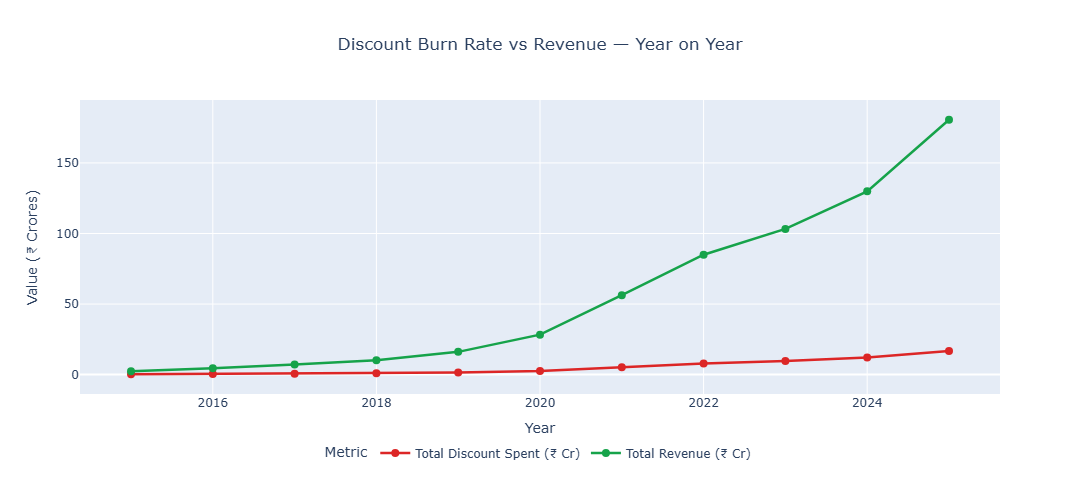

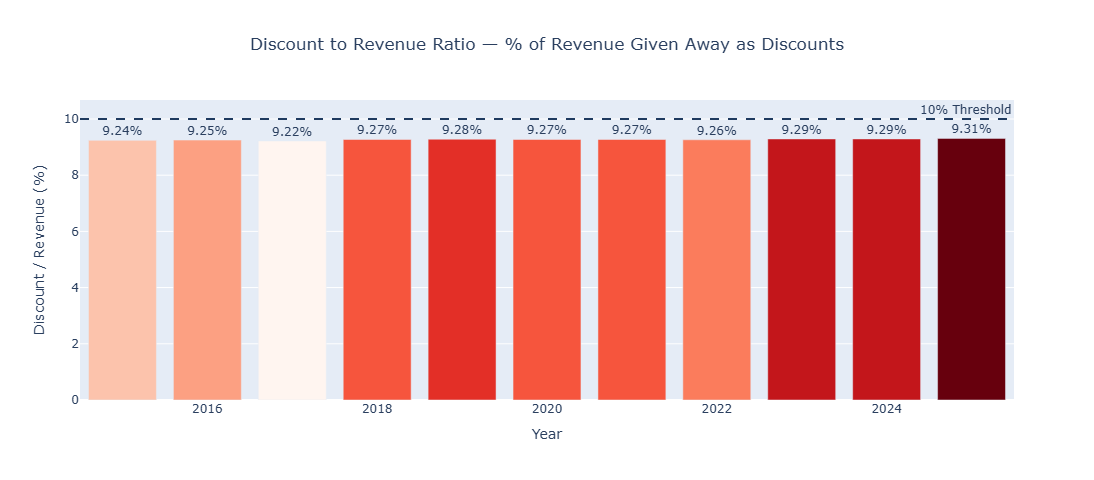

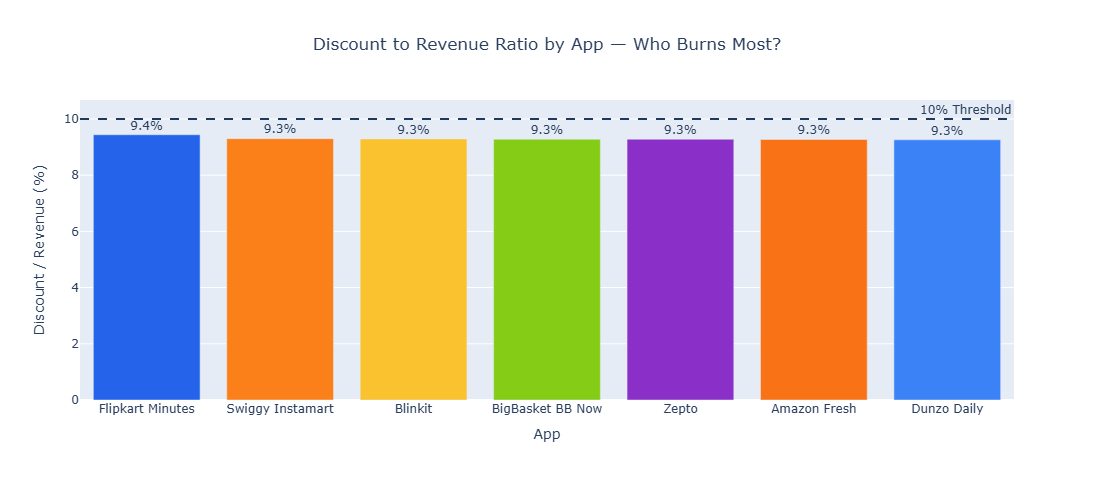

             app  discount_cr  revenue_cr  disc_to_rev_pct
Flipkart Minutes         0.73        7.74             9.44
Swiggy Instamart        12.13      130.44             9.30
         Blinkit        21.63      232.72             9.29
BigBasket BB Now         1.96       21.17             9.28
           Zepto        12.66      136.47             9.28
    Amazon Fresh         2.38       25.71             9.27
     Dunzo Daily         6.43       69.49             9.26


In [42]:
# CHART 9.2 — DISCOUNT STRATEGY ANALYSIS (Corporate Level)

# PART A: Discount Burn Rate Over Time 

# Calculate yearly metrics
burn_rate = df.groupby('year').agg(
    total_discount_rs = ('discount_rs',      'sum'),   # Total ₹ spent on discounts
    total_revenue     = ('final_amount_rs',  'sum'),   # Total revenue generated
    total_orders      = ('order_id',         'count')  # Total orders
).reset_index()

# Convert to crores for readable numbers
# 1 Crore = 10,000,000 rupees
burn_rate['discount_cr'] = (burn_rate['total_discount_rs'] / 10_000_000).round(2)
burn_rate['revenue_cr']  = (burn_rate['total_revenue']     / 10_000_000).round(2)

# Chart 1 — Discount Burn Rate vs Revenue 

# Build a long format table so both lines can be plotted together
burn_melted = burn_rate.melt(
    id_vars    = 'year',
    value_vars = ['discount_cr', 'revenue_cr'],
    var_name   = 'metric',
    value_name = 'value_cr'
)

# Rename for cleaner legend labels
burn_melted['metric'] = burn_melted['metric'].map({
    'discount_cr' : 'Total Discount Spent (₹ Cr)',
    'revenue_cr'  : 'Total Revenue (₹ Cr)'
})

fig1 = px.line(
    burn_melted,
    x                  = 'year',
    y                  = 'value_cr',
    color              = 'metric',
    markers            = True,
    title              = 'Discount Burn Rate vs Revenue — Year on Year',
    color_discrete_map = {
        'Total Discount Spent (₹ Cr)' : COLORS['cancelled'],  # Red — money going out
        'Total Revenue (₹ Cr)'        : COLORS['delivered']   # Green — money coming in
    }
)

fig1.update_traces(line_width=2.5, marker_size=8)

fig1.update_layout(
    xaxis_title = 'Year',
    yaxis_title = 'Value (₹ Crores)',
    height      = 480,
    title       = dict(x=0.5, xanchor='center'),
    legend      = dict(
        title       = 'Metric',
        orientation = 'h',
        yanchor     = 'bottom',
        y           = -0.25,
        xanchor     = 'center',
        x           = 0.5
    )
)

fig1.show()

# PART B: Discount to Revenue Ratio 

# Calculate what % of revenue is being given away as discounts
# e.g. 8% means for every ₹100 earned, ₹8 was given as discount
burn_rate['disc_to_rev_pct'] = (
    burn_rate['total_discount_rs'] / burn_rate['total_revenue'] * 100
).round(2)

# Add label text for each bar
burn_rate['label'] = burn_rate['disc_to_rev_pct'].astype(str) + '%'

fig2 = px.bar(
    burn_rate,
    x         = 'year',
    y         = 'disc_to_rev_pct',
    text      = 'label',
    title     = 'Discount to Revenue Ratio — % of Revenue Given Away as Discounts',
    color     = 'disc_to_rev_pct',              # Darker = higher discount burden
    color_continuous_scale = 'Reds'
)

fig2.update_traces(textposition='outside')

# Add a reference line at 10% — common industry threshold for discount sustainability
fig2.add_hline(
    y                = 10,
    line_dash        = 'dash',
    line_color       = COLORS['primary'],
    annotation_text  = '10% Threshold',
    annotation_position = 'top right'
)

fig2.update_layout(
    xaxis_title         = 'Year',
    yaxis_title         = 'Discount / Revenue (%)',
    height              = 480,
    title               = dict(x=0.5, xanchor='center'),
    coloraxis_showscale = False
)

fig2.show()

# PART C: Discount Burn Rate by App 
# Which app is the biggest discount spender?

app_burn = df.groupby('app').agg(
    total_discount_rs = ('discount_rs',     'sum'),
    total_revenue     = ('final_amount_rs', 'sum')
).reset_index()

# Convert to crores
app_burn['discount_cr']    = (app_burn['total_discount_rs'] / 10_000_000).round(2)
app_burn['revenue_cr']     = (app_burn['total_revenue']     / 10_000_000).round(2)

# Discount to revenue ratio per app
app_burn['disc_to_rev_pct'] = (
    app_burn['total_discount_rs'] / app_burn['total_revenue'] * 100
).round(2)

# Sort by discount burden highest first
app_burn = app_burn.sort_values('disc_to_rev_pct', ascending=False)

fig3 = px.bar(
    app_burn,
    x                  = 'app',
    y                  = 'disc_to_rev_pct',
    color              = 'app',
    text               = 'disc_to_rev_pct',
    title              = 'Discount to Revenue Ratio by App — Who Burns Most?',
    color_discrete_map = APP_COLORS
)

fig3.update_traces(
    texttemplate = '%{text:.1f}%',
    textposition = 'outside'
)

# Reference line at 10% threshold
fig3.add_hline(
    y                   = 10,
    line_dash           = 'dash',
    line_color          = COLORS['primary'],
    annotation_text     = '10% Threshold',
    annotation_position = 'top right'
)

fig3.update_layout(
    xaxis_title = 'App',
    yaxis_title = 'Discount / Revenue (%)',
    height      = 480,
    title       = dict(x=0.5, xanchor='center'),
    showlegend  = False
)

fig3.show()

print(app_burn[['app', 'discount_cr', 'revenue_cr', 'disc_to_rev_pct']].to_string(index=False))

## Insights:
- **All major Q-commerce platforms maintained a consistent discount-to-revenue ratio of approximately 9.3%**, indicating a disciplined and sustainable pricing strategy rather than excessive discounting.
- **Flipkart Minutes recorded the highest discount-to-revenue ratio (9.44%)**, while **Dunzo Daily had the lowest (9.26%)**, although the variation across platforms remained minimal.
- **Blinkit incurred the highest absolute discount spend (₹21.63 Cr)**, driven by its market-leading revenue of **₹232.72 Cr**, reflecting aggressive customer acquisition and retention efforts.
- **The discount-to-revenue ratio remained remarkably stable between 9.22% and 9.31% from 2015 to 2025**, demonstrating consistent promotional spending despite rapid industry expansion.
- **Total discount expenditure increased significantly year over year**, rising alongside revenue growth, indicating that higher promotional spending was supported by proportional business growth rather than increasing discount dependency.
- **The analysis suggests that India's Q-commerce platforms prioritized sustainable growth**, balancing customer incentives with healthy revenue generation while keeping discount burn well below the 10% benchmark.

## Phase 10 — User Type, Demographics & Retention

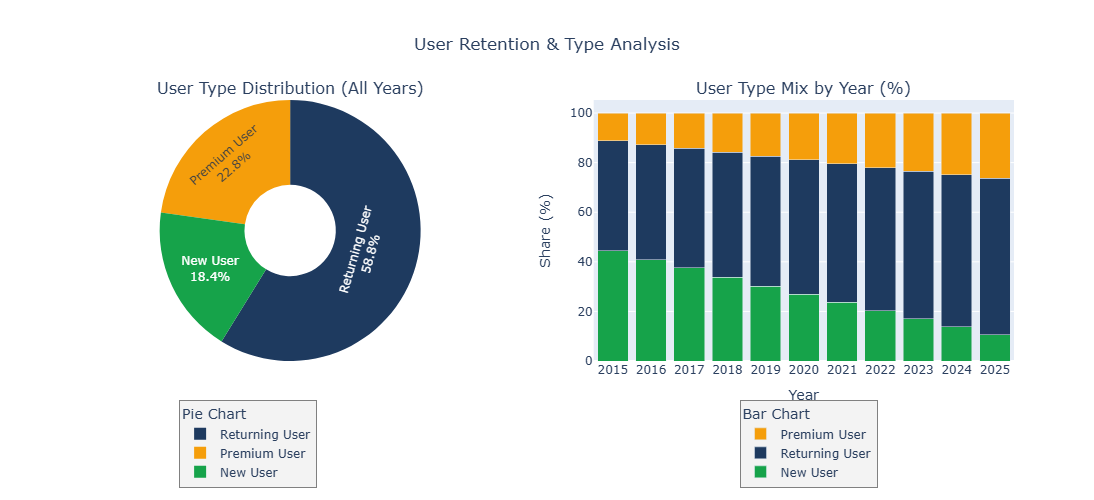

In [37]:
# CHART 10.1 — USER TYPE DISTRIBUTION & EVOLUTION

# Count orders per year + user type
user_counts   = df.groupby(["year", "user_type"]).size().reset_index(name="count")
yearly_totals = df.groupby("year").size().reset_index(name="total_users")
utype_yr      = pd.merge(user_counts, yearly_totals, on="year")
utype_yr["pct"] = (utype_yr["count"] / utype_yr["total_users"] * 100).round(2)

# All-time user type totals
utype_cnt         = df["user_type"].value_counts().reset_index()
utype_cnt.columns = ["user_type", "count"]

# User type colours
user_color_map = {
    "New User"       : COLORS["delivered"],  # Green
    "Returning User" : COLORS["primary"],    # Dark navy
    "Premium User" : COLORS["festive"]    # Amber
}

pie_colors = [user_color_map.get(u, "#94A3B8") for u in utype_cnt["user_type"]]

fig = make_subplots(
    rows           = 1, cols = 2,
    subplot_titles = ["User Type Distribution (All Years)", "User Type Mix by Year (%)"],
    specs          = [[{"type": "pie"}, {"type": "bar"}]]
)

# Donut pie — single trace
fig.add_trace(
    go.Pie(
        labels        = utype_cnt["user_type"],
        values        = utype_cnt["count"],
        hole          = 0.35,
        textinfo      = "label+percent",
        marker_colors = pie_colors,
        legend        = "legend"
    ),
    row=1, col=1
)

# Stacked bar — one trace per user type
for user_type, color in user_color_map.items():
    user_data = utype_yr[utype_yr["user_type"] == user_type]
    fig.add_trace(
        go.Bar(
            x            = user_data["year"].astype(str),
            y            = user_data["pct"],
            name         = user_type,
            marker_color = color,
            legend       = "legend2",
            showlegend   = True
        ),
        row=1, col=2
    )

fig.update_layout(
    barmode = "stack",
    title   = dict(
        text    = "User Retention & Type Analysis",
        x       = 0.5,
        xanchor = "center"
    ),
    height  = 500,
    legend  = dict(
        title       = dict(text="Pie Chart"),
        orientation = "v",
        x           = 0.18,
        y           = -0.15,
        xanchor     = "center",
        yanchor     = "top",
        bgcolor     = "rgba(240,240,240,0.8)",
        bordercolor = "grey",
        borderwidth = 1
    ),
    legend2 = dict(
        title       = dict(text="Bar Chart"),
        orientation = "v",
        x           = 0.78,
        y           = -0.15,
        xanchor     = "center",
        yanchor     = "top",
        bgcolor     = "rgba(240,240,240,0.8)",
        bordercolor = "grey",
        borderwidth = 1
    )
)

fig.update_xaxes(title_text="Year",      row=1, col=2)
fig.update_yaxes(title_text="Share (%)", row=1, col=2)

fig.show()

## Insights:
- **Returning users accounted for the majority of the customer base (58.8%)**, indicating strong customer retention and repeat purchasing behavior across Q-commerce platforms.
- **Premium users contributed 22.8% of total users**, reflecting a growing preference for subscription-based services that offer benefits such as free delivery and exclusive discounts.
- **New users represented 18.4% of the user base**, demonstrating that while customer acquisition continues, the market is increasingly driven by loyal existing customers.
- **The share of returning users increased steadily from approximately 45% in 2015 to nearly 63% in 2025**, highlighting continuous improvements in customer retention and engagement.
- **The proportion of new users declined over time**, suggesting that the industry has transitioned from rapid customer acquisition to a more mature market focused on retaining existing users.
- **Premium membership adoption increased consistently throughout the analysis period**, indicating that customers increasingly recognize the value of subscription programs and are becoming more engaged with Q-commerce platforms.

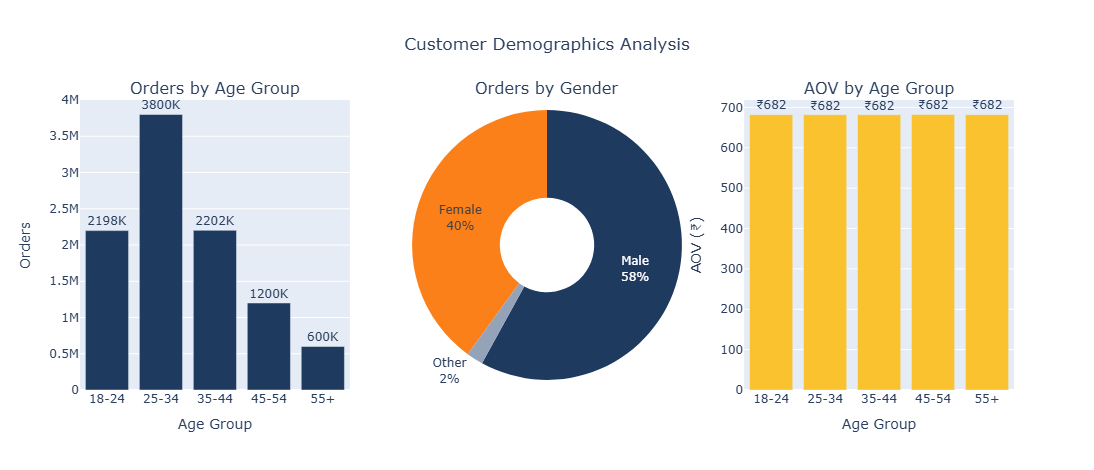

In [38]:
# CHART 10.2 — CUSTOMER DEMOGRAPHICS

# Orders by age group
age_cnt         = df["age_group"].value_counts().sort_index().reset_index()
age_cnt.columns = ["age_group", "count"]
age_cnt["text_label"] = (age_cnt["count"] / 1000).round(0).astype(int).astype(str) + "K"

# Orders by gender
gen_cnt         = df["gender"].value_counts().reset_index()
gen_cnt.columns = ["gender", "count"]

# AOV by age group — delivered orders only
delivered_df          = df[df["order_status"] == "Delivered"]
age_aov               = delivered_df.groupby("age_group")["order_amount_rs"].mean().reset_index()
age_aov["text_label"] = "₹" + age_aov["order_amount_rs"].round(0).astype(int).astype(str)

fig = make_subplots(
    rows           = 1, cols = 3,
    subplot_titles = ["Orders by Age Group", "Orders by Gender", "AOV by Age Group"],
    specs          = [[{"type": "bar"}, {"type": "pie"}, {"type": "bar"}]]
)

# Bar — orders by age group
fig.add_trace(
    go.Bar(
        x            = age_cnt["age_group"],
        y            = age_cnt["count"],
        marker_color = COLORS["primary"],              # Dark navy
        text         = age_cnt["text_label"],
        textposition = "outside",
        name         = "Age"
    ),
    row=1, col=1
)

# Pie — gender split
fig.add_trace(
    go.Pie(
        labels        = gen_cnt["gender"],
        values        = gen_cnt["count"],
        hole          = 0.35,
        marker_colors = [COLORS["primary"], COLORS["instamart"], "#94A3B8"],
        textinfo      = "label+percent"
    ),
    row=1, col=2
)

# Bar — AOV by age group
fig.add_trace(
    go.Bar(
        x            = age_aov["age_group"],
        y            = age_aov["order_amount_rs"],
        marker_color = COLORS["blinkit"],              # Yellow
        text         = age_aov["text_label"],
        textposition = "outside",
        name         = "AOV"
    ),
    row=1, col=3
)

fig.update_layout(
    height     = 470,
    showlegend = False,
    title      = dict(
        text    = "Customer Demographics Analysis",
        x       = 0.5,
        xanchor = "center"
    )
)

fig.update_xaxes(title_text="Age Group", row=1, col=1)
fig.update_yaxes(title_text="Orders",    row=1, col=1)
fig.update_xaxes(title_text="Age Group", row=1, col=3)
fig.update_yaxes(title_text="AOV (₹)",   row=1, col=3)

fig.show()

## Insights:
- **Customers aged 25–34 formed the largest customer segment**, contributing **3.8 million orders**, making young working professionals the primary users of Q-commerce services.
- **The 18–24 and 35–44 age groups each generated over 2.2 million orders**, indicating strong adoption among both young adults and middle-aged consumers.
- **Order volumes declined with increasing age**, with customers aged **55+ contributing the fewest orders (600K)**, suggesting lower adoption among older demographics.
- **Male customers accounted for 58% of total orders**, while **female customers contributed 40%** and **other genders represented 2%**, reflecting a relatively balanced customer base with room for broader demographic expansion.
- **Average Order Value (AOV) remained consistent at approximately ₹682 across all age groups**, indicating that spending per order is largely independent of customer age.
- **The combination of high order frequency among younger customers and stable AOV across demographics suggests that business growth is primarily driven by customer activity rather than higher spending per transaction.**

## Phase 11 — COVID-19 Impact & Category Evolution

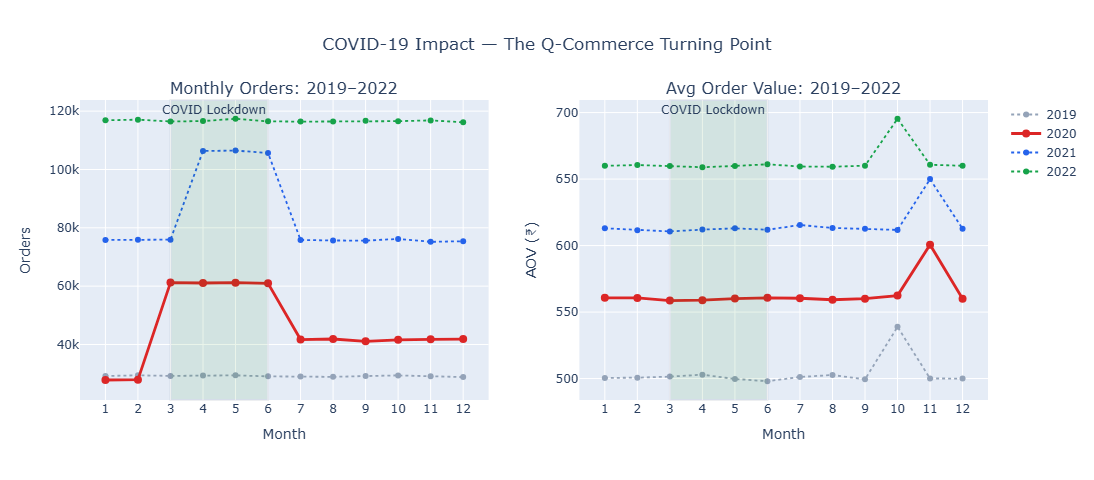

In [39]:
# CHART 11.1 — COVID IMPACT ANALYSIS

# Keep only 2019 to 2022
df_cmp = df[df["year"].between(2019, 2022)]

# Monthly metrics per year
monthly_cmp = df_cmp.groupby(["year", "month"]).agg(
    count = ("order_id",        "count"),
    aov   = ("order_amount_rs", "mean")
).reset_index()

# Year colours — 2020 highlighted in red
year_colors = {
    2019 : "#94A3B8",           # Grey — pre COVID
    2020 : COLORS["cancelled"], # Red  — COVID year
    2021 : COLORS["tier2"],     # Medium blue — recovery
    2022 : COLORS["delivered"]  # Green — normalisation
}

fig = make_subplots(
    rows           = 1, cols = 2,
    subplot_titles = ["Monthly Orders: 2019–2022", "Avg Order Value: 2019–2022"]
)

for year, color in year_colors.items():
    year_data = monthly_cmp[monthly_cmp["year"] == year]

    # 2020 thick solid line — all others thin dotted
    if year == 2020:
        line_thickness = 2.8
        line_style     = "solid"
        dot_size       = 8
    else:
        line_thickness = 1.8
        line_style     = "dot"
        dot_size       = 6

    # Monthly orders line
    fig.add_trace(
        go.Scatter(
            x      = year_data["month"],
            y      = year_data["count"],
            name   = str(year),
            mode   = "lines+markers",
            line   = dict(color=color, width=line_thickness, dash=line_style),
            marker = dict(size=dot_size)
        ),
        row=1, col=1
    )

    # AOV line
    fig.add_trace(
        go.Scatter(
            x          = year_data["month"],
            y          = year_data["aov"],
            showlegend = False,
            mode       = "lines+markers",
            line       = dict(color=color, width=line_thickness, dash=line_style),
            marker     = dict(size=dot_size)
        ),
        row=1, col=2
    )

# COVID lockdown band Mar-Jun
fig.add_vrect(
    x0              = 3, x1 = 6,
    fillcolor       = "green",
    opacity         = 0.08,
    annotation_text = "COVID Lockdown",
    row=1, col=1
)

fig.add_vrect(
    x0              = 3, x1 = 6,
    fillcolor       = "green",
    opacity         = 0.08,
    annotation_text = "COVID Lockdown",
    row=1, col=2
)

fig.update_layout(
    height  = 480,
    title   = dict(
        text    = "COVID-19 Impact — The Q-Commerce Turning Point",
        x       = 0.5,
        xanchor = "center"
    )
)

fig.update_xaxes(title_text="Month", tickmode="linear", dtick=1, row=1, col=1)
fig.update_xaxes(title_text="Month", tickmode="linear", dtick=1, row=1, col=2)
fig.update_yaxes(title_text="Orders",  row=1, col=1)
fig.update_yaxes(title_text="AOV (₹)", row=1, col=2)

fig.show()

## Insights:
- COVID-19 became the biggest growth catalyst for India's Q-Commerce industry, significantly increasing online grocery demand.
- Monthly orders nearly **doubled during the March–June 2020 lockdown** and remained well above pre-pandemic levels afterward.
- Order volumes continued to rise through **2021 and 2022**, indicating that the shift toward Q-Commerce became a long-term consumer habit.
- Average Order Value (AOV) increased steadily from **~₹500 in 2019** to **~₹660 in 2022**, showing higher customer spending per order.
- AOV consistently peaked during the **October–November festive season**, reflecting increased festive purchases.
- The sustained growth in both **order volume** and **AOV** confirms that COVID-19 permanently accelerated digital adoption and transformed Q-Commerce into a mainstream retail channel.

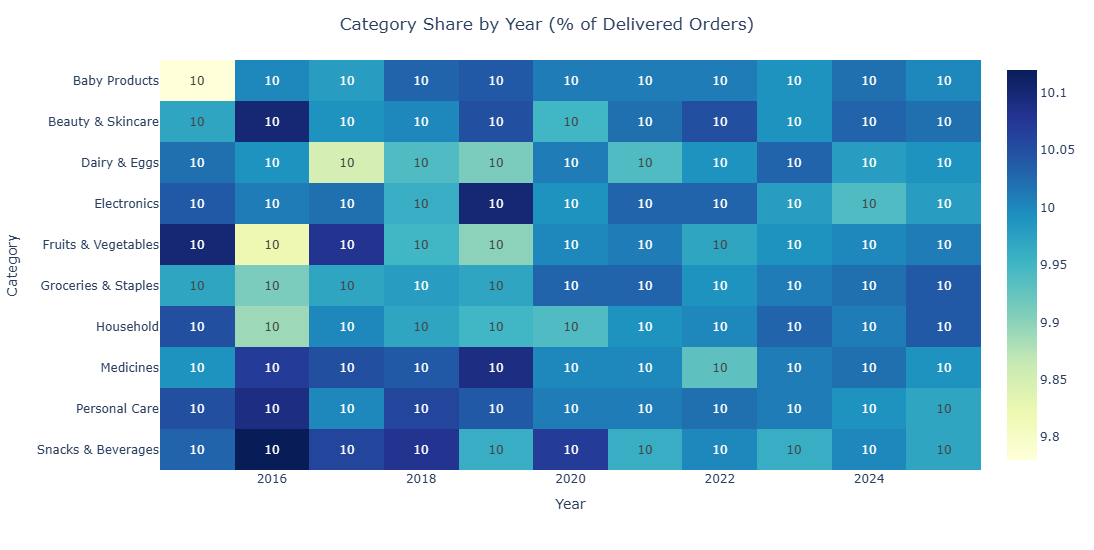

In [40]:
# CHART 11.2 — CATEGORY HEATMAP OVER YEARS

# Delivered orders only
delivered_df  = df[df["order_status"] == "Delivered"]
cat_counts    = delivered_df.groupby(["year", "category"]).size().reset_index(name="count")
yearly_totals = delivered_df.groupby("year").size().reset_index(name="total_orders")
merged_data   = pd.merge(cat_counts, yearly_totals, on="year")
merged_data["pct"] = (merged_data["count"] / merged_data["total_orders"] * 100).round(2)

# Pivot — rows = category, columns = year
heatmap_data = merged_data.pivot(index="category", columns="year", values="pct")
heatmap_data = heatmap_data.fillna(0)

fig = px.imshow(
    heatmap_data,
    text_auto              = ".0f",
    color_continuous_scale = "YlGnBu",   # Yellow to blue
    aspect                 = "auto"
)

fig.update_layout(
    height      = 550,
    xaxis_title = "Year",
    yaxis_title = "Category",
    title       = dict(
        text    = "Category Share by Year (% of Delivered Orders)",
        x       = 0.5,
        xanchor = "center"
    )
)

fig.show()

## Insights:
- Category contribution remained **highly balanced**, with each product category contributing approximately **10% of delivered orders** throughout 2015–2025.
- No single category consistently dominated the market, indicating **diversified customer demand** across all product segments.
- Essential categories such as **Groceries & Staples, Fruits & Vegetables, Dairy & Eggs, and Medicines** maintained a stable share, reflecting their importance in everyday purchases.
- Non-essential categories including **Beauty & Skincare, Personal Care, Electronics, and Baby Products** also showed consistent participation, highlighting the expanding use of Q-Commerce beyond groceries.
- The minimal year-to-year variation suggests that **overall market growth was broad-based**, with all categories growing together rather than one category driving the expansion.

# Phase 12 — Key Insights & Conclusions

---

## Top 15 Business Findings

| # | Finding | Data Evidence |
|---|---------|---------------|
| 1 | **Explosive Market Growth** | Annual orders increased from **100K (2015)** to **2.5M (2025)**, reflecting a **25× expansion** in India's Q-Commerce market. |
| 2 | **COVID-19 Was the Turning Point** | Orders nearly doubled during the **March–June 2020 lockdown**, permanently accelerating digital grocery adoption and online ordering habits. |
| 3 | **Revenue Scaled Rapidly** | Monthly revenue grew from **less than ₹0.5 Cr** in 2015 to **over ₹15 Cr** by 2025, driven by higher order volumes and increasing AOV. |
| 4 | **Higher Customer Spending** | Average Order Value (AOV) increased steadily from **₹269 (2015)** to **₹790 (2025)**, indicating customers purchased larger baskets over time. |
| 5 | **Faster Deliveries Became the Competitive Advantage** | Average delivery time improved from **~40 minutes (2015)** to **~22 minutes (2025)**, while the share of deliveries completed within **20 minutes** increased significantly. |
| 6 | **Blinkit Emerged as Market Leader** | Blinkit rapidly captured **nearly half of the market by 2025**, while legacy players such as Dunzo and Amazon Fresh gradually lost market share. |
| 7 | **2021 Triggered Hyper-Competition** | The simultaneous expansion of **Blinkit, Zepto, and BigBasket BB Now** transformed the industry into a highly competitive quick-commerce ecosystem. |
| 8 | **Expansion Beyond Metro Cities** | Tier-2 and Tier-3 city contribution increased from **almost negligible levels** to **42% of total orders by 2025**, demonstrating nationwide market penetration. |
| 9 | **UPI Became the Preferred Payment Method** | UPI adoption increased from **almost 0%** to **58% by 2025**, while Cash-on-Delivery declined from **over 80% to nearly 20%**, reflecting India's digital payment revolution. |
| 10 | **Evening Is the Peak Ordering Window** | Customer demand consistently peaked between **7 PM and 9 PM**, with additional lunchtime demand around **12 PM–1 PM**, aligning with meal consumption patterns. |
| 11 | **Customer Loyalty Improved Every Year** | Returning users accounted for **~59% of all customers**, while premium users continued to grow, indicating improving retention and platform loyalty. |
| 12 | **Young Adults Drive Demand** | Customers aged **25–34 years** generated the highest order volumes, making them the primary target demographic for Q-Commerce platforms. |
| 13 | **Balanced Category Growth** | Product categories maintained an almost equal **~10% contribution each**, indicating that market expansion was broad-based rather than dependent on a single category. |
| 14 | **Discount Spending Remained Sustainable** | All major platforms maintained a **discount-to-revenue ratio of approximately 9.3%**, suggesting disciplined promotional spending despite rapid market growth. |
| 15 | **Festive Seasons Continue to Drive Demand** | October–November consistently recorded the highest **Order Volume** and **Average Order Value**, confirming the importance of festive campaigns for revenue growth. |

---

## Overall Conclusion

The analysis demonstrates that India's Q-Commerce industry has evolved from a niche convenience service into a **large-scale, technology-driven retail ecosystem**. Rapid order growth, increasing customer spending, faster delivery times, widespread UPI adoption, and expansion into Tier-2 and Tier-3 cities have collectively fueled market expansion. While competition intensified after 2021 with the rise of Blinkit, Zepto, and BigBasket BB Now, the industry's long-term growth has been driven by strong customer retention, operational efficiency, and permanent behavioral changes accelerated by the COVID-19 pandemic.
